In [29]:
import numpy as np
import matplotlib.pyplot as plt

from graspologic.match import graph_match
import graspologic.match.wrappers as wrappers

from utils.Graphs import (
    gen_ER_graphs,
    gen_SBM_graphs,
    gen_correlated_powerlaw_graphs,
    gen_PAPER_graphs,
)

from utils.SeedingMethods import (
    random_seeds,
    blocked_random_seeds,
    highest_degree_seeds,
    blocked_highest_degree_seeds,
    betweenness_seeds,
    neighbor_degree_seeds,
    jaccard_neighborhood_seeds,
    spectral_unique_seeds,
)

from scipy.stats import spearmanr
# ============================================================
# RECORD THE INTERNAL SGM ITERATES
# ============================================================

last_solver = None


def solve_with_history(self, rng=None):
    """
    Temporary notebook-only replacement for the internal SGM solve method.

    It records:
        P_history_[i]     = relaxed iterate P^(i)
        Q_history_[i]     = Hungarian direction Q^(i)
        alpha_history_[i] = line-search coefficient alpha_i
    """
    global last_solver
    last_solver = self

    rng = np.random.default_rng(rng)

    self.n_iter_ = 0
    self.converged_ = False
    self.P_history_ = []
    self.Q_history_ = []
    self.alpha_history_ = []

    if self.n_seeds == self.n:
        P = np.empty((0, 0))
        self.converged_ = True

    else:
        # Initial relaxed matrix P^(0)
        P = self.initialize(rng)
        self.P_history_.append(P.copy())

        self.compute_constant_terms()

        for n_iter in range(self.max_iter):
            self.n_iter_ = n_iter + 1

            gradient = self.compute_gradient(P)

            # Hungarian/Frank-Wolfe direction Q^(i)
            Q = self.compute_step_direction(gradient, rng)

            # graspologic convention:
            # P^(i+1) = alpha_i P^(i) + (1-alpha_i) Q^(i)
            alpha = self.compute_step_size(P, Q)

            self.Q_history_.append(Q.copy())
            self.alpha_history_.append(float(alpha))

            P_new = alpha * P + (1.0 - alpha) * Q
            self.P_history_.append(P_new.copy())

            if self.check_converged(P, P_new):
                self.converged_ = True
                P = P_new
                break

            P = P_new

    self.finalize(P, rng)


# Apply the patch only to this notebook session
wrappers._GraphMatchSolver.solve = solve_with_history


# ============================================================
# CORRELATION HELPER
# ============================================================

def safe_correlation(x, y):
    """
    Pearson correlation, returning NaN when either variable is constant.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan

    if np.isclose(np.std(x), 0) or np.isclose(np.std(y), 0):
        return np.nan

    return np.corrcoef(x, y)[0, 1]


# ============================================================
# RUN ONE EXPERIMENTAL REGIME
# ============================================================

def run_h0_experiment(
    graph_gen_func,
    seeding_func,
    n_seeds,
    n_trials=100,
    graph_kwargs=None,
    verbose=True,
):
    """
    Run repeated seeded graph-matching trials in one fixed regime.

    Parameters
    ----------
    graph_gen_func:
        One of the graph generators imported above.

    seeding_func:
        One of the seed-selection strategies imported above.

    n_seeds:
        Number of known seed correspondences.

    n_trials:
        Number of independently generated graph pairs.

    graph_kwargs:
        Dictionary of parameters passed to the graph generator.

    Returns
    -------
    records:
        One dictionary per trial.

    summary:
        Means and correlations across trials.
    """
    if graph_kwargs is None:
        graph_kwargs = {}

    records = []

    for trial in range(n_trials):

        G1, G2_shuffled, true_perm = graph_gen_func(**graph_kwargs)
        true_perm = np.asarray(true_perm, dtype=int)

        # Select seeds using the known true matching
        seeds_G1, seeds_G2 = seeding_func(
            G1,
            G2_shuffled,
            n_seeds,
            true_perm,
        )

        seeds_G1 = np.asarray(seeds_G1, dtype=int)
        seeds_G2 = np.asarray(seeds_G2, dtype=int)

        # Verify that the seed pairs are genuinely correct
        if not np.array_equal(seeds_G2, true_perm[seeds_G1]):
            raise ValueError(
                "The seed-selection function returned incorrect seed pairs."
            )

        partial_match = np.column_stack((seeds_G1, seeds_G2))

        # Run seeded graph matching
        result = graph_match(
            G1,
            G2_shuffled,
            partial_match=partial_match,
            rng=int(np.random.randint(0, 2**32)),
        )

        if last_solver is None:
            raise RuntimeError("The internal SGM solver was not recorded.")

        if len(last_solver.Q_history_) == 0:
            raise RuntimeError("No Frank-Wolfe direction was recorded.")

        # ====================================================
        # FIRST DIRECTION Q^(0)
        # ====================================================

        Q0 = last_solver.Q_history_[0]

        # The solver reorders vertices internally.
        # These recover the original G1 and G2 labels represented
        # by the rows and columns of Q0.
        rows_A = last_solver.perm_A[last_solver.n_seeds:]
        cols_B = last_solver.perm_B[last_solver.n_seeds:]

        # Since Q0 is a permutation matrix, each row has one chosen column
        predicted_column_positions = np.argmax(Q0, axis=1)
        predicted_B_from_Q0 = cols_B[predicted_column_positions]

        # True G2 matches of the corresponding G1 row labels
        true_B_for_rows = true_perm[rows_A]

        # First-direction match ratio on unseeded vertices
        H0 = np.mean(predicted_B_from_Q0 == true_B_for_rows)

        # ====================================================
        # FINAL SGM PERMUTATION
        # ====================================================

        predicted_perm = np.empty_like(true_perm)
        predicted_perm[result.indices_A] = result.indices_B

        all_vertices = np.arange(len(true_perm))

        unseeded_A = np.setdiff1d(
            all_vertices,
            seeds_G1,
            assume_unique=False,
        )

        final_unseeded = np.mean(
            predicted_perm[unseeded_A]
            == true_perm[unseeded_A]
        )

        final_all = np.mean(
            predicted_perm == true_perm
        )

        alpha0 = last_solver.alpha_history_[0]
        step_toward_Q0 = 1.0 - alpha0

        records.append(
            {
                "trial": trial + 1,
                "H0": float(H0),
                "final_unseeded": float(final_unseeded),
                "final_all": float(final_all),
                "alpha0": float(alpha0),
                "step_toward_Q0": float(step_toward_Q0),
                "n_iter": int(last_solver.n_iter_),
            }
        )

        if verbose:
            print(
                f"trial {trial + 1:>3}: "
                f"H0={H0:.4f}, "
                f"final_unseeded={final_unseeded:.4f}, "
                f"final_all={final_all:.4f}, "
                f"step_to_Q0={step_toward_Q0:.4f}"
            )

    H0_values = np.array(
        [record["H0"] for record in records]
    )

    final_unseeded_values = np.array(
        [record["final_unseeded"] for record in records]
    )

    final_all_values = np.array(
        [record["final_all"] for record in records]
    )

    alpha0_values = np.array(
        [record["alpha0"] for record in records]
    )

    correlation = safe_correlation(
        H0_values,
        final_unseeded_values,
    )

    if (
        np.isclose(np.std(H0_values), 0)
        or np.isclose(np.std(final_unseeded_values), 0)
    ):
        spearman_correlation = np.nan
    else:
        spearman_correlation = spearmanr(
            H0_values,
            final_unseeded_values,
        ).statistic

    summary = {
        "n_trials": n_trials,
        "mean_H0": float(np.mean(H0_values)),
        "std_H0": float(np.std(H0_values)),
        "mean_final_unseeded": float(
            np.mean(final_unseeded_values)
        ),
        "std_final_unseeded": float(
            np.std(final_unseeded_values)
        ),
        "mean_final_all": float(
            np.mean(final_all_values)
        ),
        "mean_alpha0": float(
            np.mean(alpha0_values)
        ),
        "correlation_H0_final_unseeded": float(correlation),
        "spearman_H0_final_unseeded": float(spearman_correlation),
    }

    print("\nSummary")
    print("-------")
    print(f"Trials:                       {summary['n_trials']}")
    print(f"Mean H0:                      {summary['mean_H0']:.4f}")
    print(f"Standard deviation of H0:     {summary['std_H0']:.4f}")
    print(
        "Mean final unseeded ratio:   "
        f"{summary['mean_final_unseeded']:.4f}"
    )
    print(
        "Std. final unseeded ratio:   "
        f"{summary['std_final_unseeded']:.4f}"
    )
    print(
        "Mean final all-vertex ratio: "
        f"{summary['mean_final_all']:.4f}"
    )
    print(f"Mean alpha0:                  {summary['mean_alpha0']:.4f}")

    if np.isnan(correlation):
        print(
            "Pearson(H0, final):          NaN "
            "(one variable was constant)"
        )
    else:
        print(
            "Pearson(H0, final):          "
            f"{correlation:.4f}"
        )

    if np.isnan(spearman_correlation):
        print(
            "Spearman(H0, final):         NaN "
            "(one variable was constant)"
        )
    else:
        print(
            "Spearman(H0, final):         "
            f"{spearman_correlation:.4f}"
        )

    return records, summary


# ============================================================
# PLOT THE RESULT
# ============================================================

def plot_h0_vs_final(
    records,
    title="First-direction accuracy versus final SGM accuracy",
    add_linear_fit=True,
):
    """
    Scatterplot of H0 against final unseeded match ratio.

    The regression line is only a visual summary. The raw scatterplot
    remains important because the relationship may be threshold-like.
    """
    x = np.array(
        [record["H0"] for record in records],
        dtype=float,
    )

    y = np.array(
        [record["final_unseeded"] for record in records],
        dtype=float,
    )

    correlation = safe_correlation(x, y)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.75)

    if (
        add_linear_fit
        and len(x) >= 2
        and not np.isclose(np.std(x), 0)
    ):
        slope, intercept = np.polyfit(x, y, 1)

        x_line = np.linspace(
            np.min(x),
            np.max(x),
            200,
        )

        y_line = slope * x_line + intercept

        plt.plot(
            x_line,
            y_line,
            linewidth=2,
            label="Least-squares line",
        )

        plt.legend()

    plt.xlabel(r"First-direction match ratio $H_0$")
    plt.ylabel("Final unseeded match ratio")

    if np.isnan(correlation):
        full_title = title + "\nPearson correlation undefined"
    else:
        full_title = (
            title
            + f"\nPearson correlation = {correlation:.4f}"
        )

    plt.title(full_title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def compare_strategy_summaries(results_by_strategy):
    """
    results_by_strategy should look like:

    {
        "Random": summary_random,
        "Highest degree": summary_highest_degree,
        ...
    }
    """
    rows = []

    for strategy_name, summary in results_by_strategy.items():
        rows.append(
            {
                "Strategy": strategy_name,
                "Mean H0": summary["mean_H0"],
                "Std H0": summary["std_H0"],
                "Mean final unseeded": summary["mean_final_unseeded"],
                "Std final unseeded": summary["std_final_unseeded"],
                "Correlation": summary["correlation_H0_final_unseeded"],
                "Spearman": summary["spearman_H0_final_unseeded"],
            }
        )

    rows = sorted(
        rows,
        key=lambda row: row["Mean final unseeded"],
        reverse=True,
    )

    print(
        f"{'Strategy':<24}"
        f"{'Mean H0':>10}"
        f"{'Std H0':>10}"
        f"{'Mean final':>14}"
        f"{'Std final':>12}"
        f"{'Correlation':>14}"
        f"{'Spearman':>12}"
    )
    print("-" * 84)

    for row in rows:
        print(
            f"{row['Strategy']:<24}"
            f"{row['Mean H0']:>10.4f}"
            f"{row['Std H0']:>10.4f}"
            f"{row['Mean final unseeded']:>14.4f}"
            f"{row['Std final unseeded']:>12.4f}"
            f"{row['Correlation']:>14.4f}"
            f"{row['Spearman']:>12.4f}"
        )

    return rows


def plot_strategy_results(
    records_by_strategy,
    graph_name="ER",
    n=300,
    p=0.2,
    rho=0.3,
    n_seeds=20,
):
    for strategy_name, records in records_by_strategy.items():
        plot_h0_vs_final(
            records,
            title=(
                f"{graph_name}, {strategy_name}: "
                f"n={n}, p={p}, rho={rho}, seeds={n_seeds}"
            ),
        )

print("Experiment code is ready.")

Experiment code is ready.


In [ ]:
def run_paired_er_experiment(
    rho,
    n=300,
    p=0.2,
    n_seeds=20,
    n_trials=100,
    verbose=False,
):
    """
    For each trial:
        1. Generate one ER graph pair.
        2. Run every seed strategy on that same graph pair.
        3. Record H0 and final accuracy for each strategy.
    """

    strategies = {
        "Random": random_seeds,
        "Highest degree": highest_degree_seeds,
        "Betweenness": betweenness_seeds,
        "Neighbor degree": neighbor_degree_seeds,
        "Jaccard neighborhood": jaccard_neighborhood_seeds,
        "Spectral unique": spectral_unique_seeds,
    }

    records_by_strategy = {
        strategy_name: []
        for strategy_name in strategies
    }

    for trial in range(n_trials):

        # Generate ONE graph pair for this trial
        G1, G2_shuffled, true_perm = gen_ER_graphs(
            n=n,
            p=p,
            rho=rho,
        )

        true_perm = np.asarray(true_perm, dtype=int)

        # Run every strategy on this same graph pair
        for strategy_name, seeding_func in strategies.items():

            seeds_G1, seeds_G2 = seeding_func(
                G1,
                G2_shuffled,
                n_seeds,
                true_perm,
            )

            seeds_G1 = np.asarray(seeds_G1, dtype=int)
            seeds_G2 = np.asarray(seeds_G2, dtype=int)

            if not np.array_equal(
                seeds_G2,
                true_perm[seeds_G1],
            ):
                raise ValueError(
                    f"{strategy_name} returned incorrect seed pairs."
                )

            partial_match = np.column_stack(
                (seeds_G1, seeds_G2)
            )

            result = graph_match(
                G1,
                G2_shuffled,
                partial_match=partial_match,
                rng=int(np.random.randint(0, 2**32)),
            )

            if last_solver is None:
                raise RuntimeError(
                    "The internal SGM solver was not recorded."
                )

            if len(last_solver.Q_history_) == 0:
                raise RuntimeError(
                    "No Frank-Wolfe direction was recorded."
                )

            # ----------------------------
            # First direction Q^(0)
            # ----------------------------
            Q0 = last_solver.Q_history_[0]

            rows_A = last_solver.perm_A[
                last_solver.n_seeds:
            ]

            cols_B = last_solver.perm_B[
                last_solver.n_seeds:
            ]

            predicted_positions = np.argmax(
                Q0,
                axis=1,
            )

            predicted_B_from_Q0 = cols_B[
                predicted_positions
            ]

            true_B_for_rows = true_perm[rows_A]

            H0 = np.mean(
                predicted_B_from_Q0
                == true_B_for_rows
            )

            # ----------------------------
            # Final permutation
            # ----------------------------
            predicted_perm = np.empty_like(
                true_perm
            )

            predicted_perm[
                result.indices_A
            ] = result.indices_B

            all_vertices = np.arange(
                len(true_perm)
            )

            unseeded_A = np.setdiff1d(
                all_vertices,
                seeds_G1,
                assume_unique=False,
            )

            final_unseeded = np.mean(
                predicted_perm[unseeded_A]
                == true_perm[unseeded_A]
            )

            final_all = np.mean(
                predicted_perm == true_perm
            )

            alpha0 = last_solver.alpha_history_[0]

            records_by_strategy[
                strategy_name
            ].append(
                {
                    "trial": trial + 1,
                    "H0": float(H0),
                    "final_unseeded": float(
                        final_unseeded
                    ),
                    "final_all": float(final_all),
                    "alpha0": float(alpha0),
                    "step_toward_Q0": float(
                        1.0 - alpha0
                    ),
                    "n_iter": int(
                        last_solver.n_iter_
                    ),
                }
            )

        if verbose:
            print(
                f"Completed paired trial "
                f"{trial + 1}/{n_trials}"
            )

    # Build one summary per strategy
    summaries_by_strategy = {}

    for strategy_name, records in (
        records_by_strategy.items()
    ):

        H0_values = np.array(
            [record["H0"] for record in records]
        )

        final_values = np.array(
            [
                record["final_unseeded"]
                for record in records
            ]
        )

        final_all_values = np.array(
            [
                record["final_all"]
                for record in records
            ]
        )

        alpha_values = np.array(
            [
                record["alpha0"]
                for record in records
            ]
        )

        pearson = safe_correlation(
            H0_values,
            final_values,
        )

        if (
            np.isclose(np.std(H0_values), 0)
            or np.isclose(
                np.std(final_values),
                0,
            )
        ):
            spearman = np.nan
        else:
            spearman = spearmanr(
                H0_values,
                final_values,
            ).statistic

        summaries_by_strategy[
            strategy_name
        ] = {
            "n_trials": n_trials,
            "mean_H0": float(
                np.mean(H0_values)
            ),
            "std_H0": float(
                np.std(H0_values)
            ),
            "mean_final_unseeded": float(
                np.mean(final_values)
            ),
            "std_final_unseeded": float(
                np.std(final_values)
            ),
            "mean_final_all": float(
                np.mean(final_all_values)
            ),
            "mean_alpha0": float(
                np.mean(alpha_values)
            ),
            "correlation_H0_final_unseeded": float(
                pearson
            ),
            "spearman_H0_final_unseeded": float(
                spearman
            ),
        }

    return (
        records_by_strategy,
        summaries_by_strategy,
    )

In [ ]:
def run_paired_sbm_experiment(
    rho,
    n_per_block=100,
    n_blocks=3,
    block_probs=None,
    n_seeds=20,
    n_trials=100,
    verbose=False,
):
    """
    For each trial:
        1. Generate one correlated SBM graph pair.
        2. Run every seed strategy on that same graph pair.
        3. Record H0 and final accuracy for each strategy.
    """

    if block_probs is None:
        block_probs = np.array(
            [
                [0.3, 0.1, 0.1],
                [0.1, 0.3, 0.1],
                [0.1, 0.1, 0.3],
            ]
        )

    strategies = {
        "Random": random_seeds,
        "Blocked random": blocked_random_seeds,
        "Highest degree": highest_degree_seeds,
        "Blocked highest degree": blocked_highest_degree_seeds,
        "Betweenness": betweenness_seeds,
        "Neighbor degree": neighbor_degree_seeds,
        "Jaccard neighborhood": jaccard_neighborhood_seeds,
        "Spectral unique": spectral_unique_seeds,
    }

    records_by_strategy = {
        strategy_name: []
        for strategy_name in strategies
    }

    for trial in range(n_trials):

        # Generate ONE SBM pair for this trial
        G1, G2_shuffled, true_perm = gen_SBM_graphs(
            directed=False,
            loops=False,
            n_per_block=n_per_block,
            n_blocks=n_blocks,
            rho=rho,
            block_probs=block_probs,
        )

        true_perm = np.asarray(true_perm, dtype=int)

        # Run every strategy on this same graph pair
        for strategy_name, seeding_func in strategies.items():

            if strategy_name == "Blocked random":
                seeds_G1, seeds_G2 = seeding_func(
                    G1,
                    G2_shuffled,
                    n_seeds,
                    true_perm,
                    n_blocks=n_blocks,
                )

            elif strategy_name == "Blocked highest degree":
                seeds_G1, seeds_G2 = seeding_func(
                    G1,
                    G2_shuffled,
                    n_seeds,
                    true_perm,
                    n_blocks=n_blocks,
                    n_per_block=n_per_block,
                )

            else:
                seeds_G1, seeds_G2 = seeding_func(
                    G1,
                    G2_shuffled,
                    n_seeds,
                    true_perm,
                )

            seeds_G1 = np.asarray(seeds_G1, dtype=int)
            seeds_G2 = np.asarray(seeds_G2, dtype=int)

            if not np.array_equal(
                seeds_G2,
                true_perm[seeds_G1],
            ):
                raise ValueError(
                    f"{strategy_name} returned incorrect seed pairs."
                )

            partial_match = np.column_stack(
                (seeds_G1, seeds_G2)
            )

            result = graph_match(
                G1,
                G2_shuffled,
                partial_match=partial_match,
                rng=int(np.random.randint(0, 2**32)),
            )

            if last_solver is None:
                raise RuntimeError(
                    "The internal SGM solver was not recorded."
                )

            if len(last_solver.Q_history_) == 0:
                raise RuntimeError(
                    "No Frank-Wolfe direction was recorded."
                )

            # ----------------------------
            # First direction Q^(0)
            # ----------------------------
            Q0 = last_solver.Q_history_[0]

            rows_A = last_solver.perm_A[
                last_solver.n_seeds:
            ]

            cols_B = last_solver.perm_B[
                last_solver.n_seeds:
            ]

            predicted_positions = np.argmax(
                Q0,
                axis=1,
            )

            predicted_B_from_Q0 = cols_B[
                predicted_positions
            ]

            true_B_for_rows = true_perm[rows_A]

            H0 = np.mean(
                predicted_B_from_Q0
                == true_B_for_rows
            )

            # ----------------------------
            # Final permutation
            # ----------------------------
            predicted_perm = np.empty_like(
                true_perm
            )

            predicted_perm[
                result.indices_A
            ] = result.indices_B

            all_vertices = np.arange(
                len(true_perm)
            )

            unseeded_A = np.setdiff1d(
                all_vertices,
                seeds_G1,
                assume_unique=False,
            )

            final_unseeded = np.mean(
                predicted_perm[unseeded_A]
                == true_perm[unseeded_A]
            )

            final_all = np.mean(
                predicted_perm == true_perm
            )

            alpha0 = last_solver.alpha_history_[0]

            records_by_strategy[
                strategy_name
            ].append(
                {
                    "trial": trial + 1,
                    "H0": float(H0),
                    "final_unseeded": float(
                        final_unseeded
                    ),
                    "final_all": float(final_all),
                    "alpha0": float(alpha0),
                    "step_toward_Q0": float(
                        1.0 - alpha0
                    ),
                    "n_iter": int(
                        last_solver.n_iter_
                    ),
                }
            )

        if verbose:
            print(
                f"Completed paired trial "
                f"{trial + 1}/{n_trials}"
            )

    # Build one summary per strategy
    summaries_by_strategy = {}

    for strategy_name, records in (
        records_by_strategy.items()
    ):

        H0_values = np.array(
            [record["H0"] for record in records]
        )

        final_values = np.array(
            [
                record["final_unseeded"]
                for record in records
            ]
        )

        final_all_values = np.array(
            [
                record["final_all"]
                for record in records
            ]
        )

        alpha_values = np.array(
            [
                record["alpha0"]
                for record in records
            ]
        )

        pearson = safe_correlation(
            H0_values,
            final_values,
        )

        if (
            np.isclose(np.std(H0_values), 0)
            or np.isclose(
                np.std(final_values),
                0,
            )
        ):
            spearman = np.nan
        else:
            spearman = spearmanr(
                H0_values,
                final_values,
            ).statistic

        perfect_recovery_rate = np.mean(
            np.isclose(final_values, 1.0)
        )

        summaries_by_strategy[
            strategy_name
        ] = {
            "n_trials": n_trials,
            "mean_H0": float(
                np.mean(H0_values)
            ),
            "std_H0": float(
                np.std(H0_values)
            ),
            "mean_final_unseeded": float(
                np.mean(final_values)
            ),
            "std_final_unseeded": float(
                np.std(final_values)
            ),
            "mean_final_all": float(
                np.mean(final_all_values)
            ),
            "mean_alpha0": float(
                np.mean(alpha_values)
            ),
            "perfect_recovery_rate": float(
                perfect_recovery_rate
            ),
            "correlation_H0_final_unseeded": float(
                pearson
            ),
            "spearman_H0_final_unseeded": float(
                spearman
            ),
        }

    return (
        records_by_strategy,
        summaries_by_strategy,
    )

In [31]:
import pickle
from pathlib import Path


def run_random_rho_sweep(
    graph_gen_func,
    rho_values,
    graph_kwargs,
    graph_name,
    n_seeds=20,
    n_trials=500,
    save_filename=None,
):
    """
    Run random-seed experiments over a grid of rho values.

    For each fixed rho, this records:
        - all trial-level results
        - mean final unseeded accuracy
        - Pearson(H0, final unseeded accuracy)
        - Spearman(H0, final unseeded accuracy)

    Parameters
    ----------
    graph_gen_func:
        Graph generator, such as gen_SBM_graphs.

    rho_values:
        Iterable of graph-correlation values.

    graph_kwargs:
        Fixed graph-generator arguments other than rho.

    graph_name:
        Name used in printed output and figures.

    n_seeds:
        Number of random seeds.

    n_trials:
        Number of trials at each fixed rho.

    save_filename:
        Optional pickle filename for saving all raw records and summaries.

    Returns
    -------
    sweep_results:
        Dictionary containing all records and summaries indexed by rho.
    """

    rho_values = np.asarray(rho_values, dtype=float)

    sweep_results = {
        "graph_name": graph_name,
        "n_seeds": n_seeds,
        "n_trials": n_trials,
        "graph_kwargs": graph_kwargs.copy(),
        "rho_values": rho_values.tolist(),
        "records_by_rho": {},
        "summaries_by_rho": {},
    }

    for rho_index, rho in enumerate(rho_values, start=1):

        print("\n" + "=" * 70)
        print(
            f"{graph_name}: rho={rho:.2f} "
            f"({rho_index}/{len(rho_values)})"
        )
        print("=" * 70)

        current_graph_kwargs = graph_kwargs.copy()
        current_graph_kwargs["rho"] = float(rho)

        records, summary = run_h0_experiment(
            graph_gen_func=graph_gen_func,
            seeding_func=random_seeds,
            n_seeds=n_seeds,
            n_trials=n_trials,
            graph_kwargs=current_graph_kwargs,
            verbose=False,
        )

        # Add perfect-recovery rate at this rho
        final_values = np.array(
            [
                record["final_unseeded"]
                for record in records
            ],
            dtype=float,
        )

        summary["perfect_recovery_rate"] = float(
            np.mean(np.isclose(final_values, 1.0))
        )

        sweep_results["records_by_rho"][float(rho)] = records
        sweep_results["summaries_by_rho"][float(rho)] = summary

        # Save after every rho so progress is not lost
        if save_filename is not None:
            save_path = Path(save_filename)

            with open(save_path, "wb") as file:
                pickle.dump(sweep_results, file)

            print(f"Saved progress to: {save_path}")

    return sweep_results


def print_rho_sweep_summary(sweep_results):
    """
    Print one summary row for every rho value.
    """

    print(
        f"{'rho':>6}"
        f"{'Mean H0':>12}"
        f"{'Mean final':>14}"
        f"{'Std final':>12}"
        f"{'Perfect':>11}"
        f"{'Pearson':>12}"
        f"{'Spearman':>12}"
    )
    print("-" * 79)

    for rho in sweep_results["rho_values"]:

        summary = sweep_results[
            "summaries_by_rho"
        ][float(rho)]

        print(
            f"{rho:>6.2f}"
            f"{summary['mean_H0']:>12.4f}"
            f"{summary['mean_final_unseeded']:>14.4f}"
            f"{summary['std_final_unseeded']:>12.4f}"
            f"{summary['perfect_recovery_rate']:>11.4f}"
            f"{summary['correlation_H0_final_unseeded']:>12.4f}"
            f"{summary['spearman_H0_final_unseeded']:>12.4f}"
        )


def plot_rho_sweep_figures(sweep_results):
    """
    Produce the two primary figures.

    Figure 1:
        Mean final unseeded accuracy versus rho.

    Figure 2:
        Pearson and Spearman correlations between H0 and
        final unseeded accuracy versus rho.
    """

    graph_name = sweep_results["graph_name"]
    n_trials = sweep_results["n_trials"]

    rho_values = np.array(
        sweep_results["rho_values"],
        dtype=float,
    )

    summaries = [
        sweep_results["summaries_by_rho"][float(rho)]
        for rho in rho_values
    ]

    mean_final = np.array(
        [
            summary["mean_final_unseeded"]
            for summary in summaries
        ],
        dtype=float,
    )

    std_final = np.array(
        [
            summary["std_final_unseeded"]
            for summary in summaries
        ],
        dtype=float,
    )

    standard_error = std_final / np.sqrt(n_trials)
    margin_95 = 1.96 * standard_error

    pearson_values = np.array(
        [
            summary["correlation_H0_final_unseeded"]
            for summary in summaries
        ],
        dtype=float,
    )

    spearman_values = np.array(
        [
            summary["spearman_H0_final_unseeded"]
            for summary in summaries
        ],
        dtype=float,
    )

    # ========================================================
    # FIGURE 1: Recovery curve
    # ========================================================

    plt.figure(figsize=(8, 6))

    plt.plot(
        rho_values,
        mean_final,
        marker="o",
        linewidth=2,
        label="Mean final unseeded accuracy",
    )

    plt.fill_between(
        rho_values,
        mean_final - margin_95,
        mean_final + margin_95,
        alpha=0.2,
        label="Approximate 95% confidence interval",
    )

    plt.xlabel(r"Graph correlation $\rho$")
    plt.ylabel("Mean final unseeded match ratio")
    plt.title(
        f"{graph_name}: final SGM accuracy versus "
        r"graph correlation $\rho$"
    )
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ========================================================
    # FIGURE 2: Correlation curve
    # ========================================================

    plt.figure(figsize=(8, 6))

    plt.plot(
        rho_values,
        pearson_values,
        marker="o",
        linewidth=2,
        label="Pearson",
    )

    plt.plot(
        rho_values,
        spearman_values,
        marker="s",
        linewidth=2,
        label="Spearman",
    )

    plt.axhline(
        0,
        linewidth=1,
        linestyle="--",
    )

    plt.xlabel(r"Graph correlation $\rho$")
    plt.ylabel(
        r"Correlation between $H_0$ and final accuracy"
    )
    plt.title(
        f"{graph_name}: first-direction/final-accuracy "
        "correlation"
    )
    plt.ylim(-1.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_rho_sweep(filename):
    """
    Reload a saved experiment without rerunning all trials.
    """

    with open(filename, "rb") as file:
        return pickle.load(file)


print("Random-seed rho-sweep code is ready.")

Random-seed rho-sweep code is ready.


In [5]:
sbm_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

sbm_block_probs = np.array(
    [
        [0.3, 0.1, 0.1],
        [0.1, 0.3, 0.1],
        [0.1, 0.1, 0.3],
    ]
)

sbm_sweep = run_random_rho_sweep(
    graph_gen_func=gen_SBM_graphs,
    rho_values=sbm_rho_values,
    graph_kwargs={
        "directed": False,
        "loops": False,
        "n_per_block": 100,
        "n_blocks": 3,
        "block_probs": sbm_block_probs,
    },
    graph_name="SBM",
    n_seeds=20,
    n_trials=500,
    save_filename="sbm_random_500_trials.pkl",
)


SBM: rho=0.10 (1/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0173
Standard deviation of H0:     0.0080
Mean final unseeded ratio:   0.0180
Std. final unseeded ratio:   0.0083
Mean final all-vertex ratio: 0.0834
Mean alpha0:                  0.0000
Pearson(H0, final):          0.3690
Spearman(H0, final):         0.3410
Saved progress to: sbm_random_500_trials.pkl

SBM: rho=0.20 (2/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0396
Standard deviation of H0:     0.0122
Mean final unseeded ratio:   0.0339
Std. final unseeded ratio:   0.0124
Mean final all-vertex ratio: 0.0983
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5167
Spearman(H0, final):         0.5072
Saved progress to: sbm_random_500_trials.pkl

SBM: rho=0.30 (3/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0802
Standard deviation of H0:     0.0166
Mean final unseeded ratio:   0.0930
St

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.10      0.0173        0.0180      0.0083     0.0000      0.3690      0.3410
  0.20      0.0396        0.0339      0.0124     0.0000      0.5167      0.5072
  0.30      0.0802        0.0930      0.0329     0.0000      0.6145      0.6364
  0.40      0.1419        0.9889      0.0932     0.9860      0.1728      0.1761
  0.50      0.2373        1.0000      0.0000     1.0000         nan         nan
  0.60      0.3701        1.0000      0.0000     1.0000         nan         nan
  0.70      0.5368        1.0000      0.0000     1.0000         nan         nan
  0.80      0.7211        1.0000      0.0000     1.0000         nan         nan


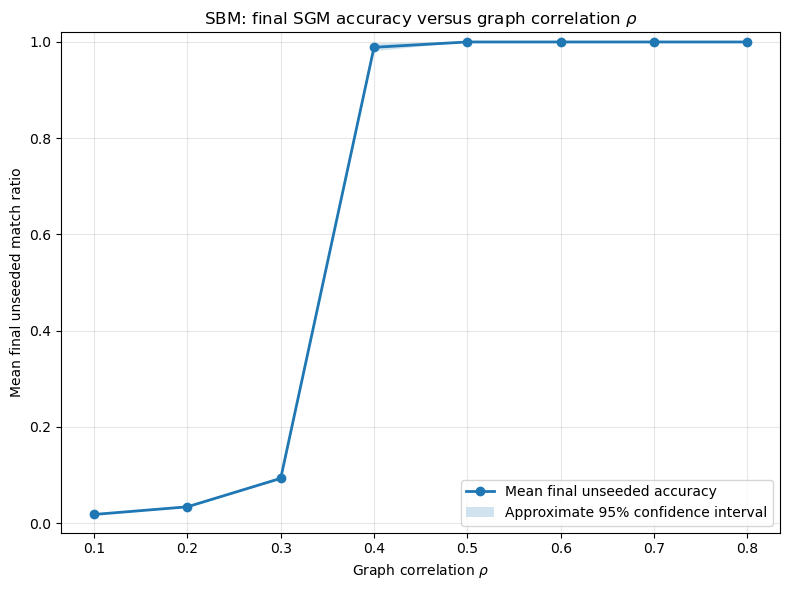

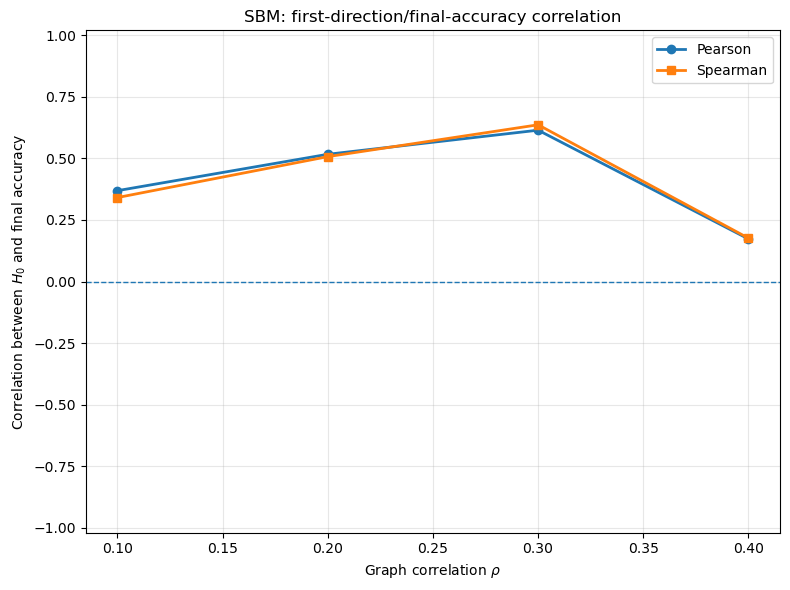

In [7]:
print_rho_sweep_summary(sbm_sweep)

plot_rho_sweep_figures(sbm_sweep)

In [9]:
sbm_rho_values_fine = np.arange(
    0.30,
    0.401,
    0.01,
)

sbm_sweep_fine = run_random_rho_sweep(
    graph_gen_func=gen_SBM_graphs,
    rho_values=sbm_rho_values_fine,
    graph_kwargs={
        "directed": False,
        "loops": False,
        "n_per_block": 100,
        "n_blocks": 3,
        "block_probs": sbm_block_probs,
    },
    graph_name="SBM fine sweep",
    n_seeds=20,
    n_trials=500,
    save_filename="sbm_random_fine_500_trials.pkl",
)


SBM fine sweep: rho=0.30 (1/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0785
Standard deviation of H0:     0.0161
Mean final unseeded ratio:   0.0906
Std. final unseeded ratio:   0.0340
Mean final all-vertex ratio: 0.1512
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6310
Spearman(H0, final):         0.6193
Saved progress to: sbm_random_fine_500_trials.pkl

SBM fine sweep: rho=0.31 (2/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0830
Standard deviation of H0:     0.0161
Mean final unseeded ratio:   0.1003
Std. final unseeded ratio:   0.0375
Mean final all-vertex ratio: 0.1603
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6148
Spearman(H0, final):         0.6073
Saved progress to: sbm_random_fine_500_trials.pkl

SBM fine sweep: rho=0.32 (3/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0892
Standard deviation of H0:    

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.30      0.0785        0.0906      0.0340     0.0000      0.6310      0.6193
  0.31      0.0830        0.1003      0.0375     0.0000      0.6148      0.6073
  0.32      0.0892        0.1266      0.0710     0.0020      0.5727      0.7047
  0.33      0.0942        0.1535      0.1249     0.0160      0.5043      0.7156
  0.34      0.0997        0.2319      0.2374     0.0760      0.5528      0.6644
  0.35      0.1045        0.3307      0.3192     0.1700      0.5226      0.7085
  0.36      0.1124        0.5221      0.3963     0.3920      0.6184      0.6888
  0.37      0.1210        0.7265      0.3739     0.6420      0.6291      0.6494
  0.38      0.1277        0.8509      0.3047     0.8000      0.5145      0.5312
  0.39      0.1342        0.9318      0.2211     0.9100      0.4674      0.4105
  0.40      0.1425        0.9795      0.

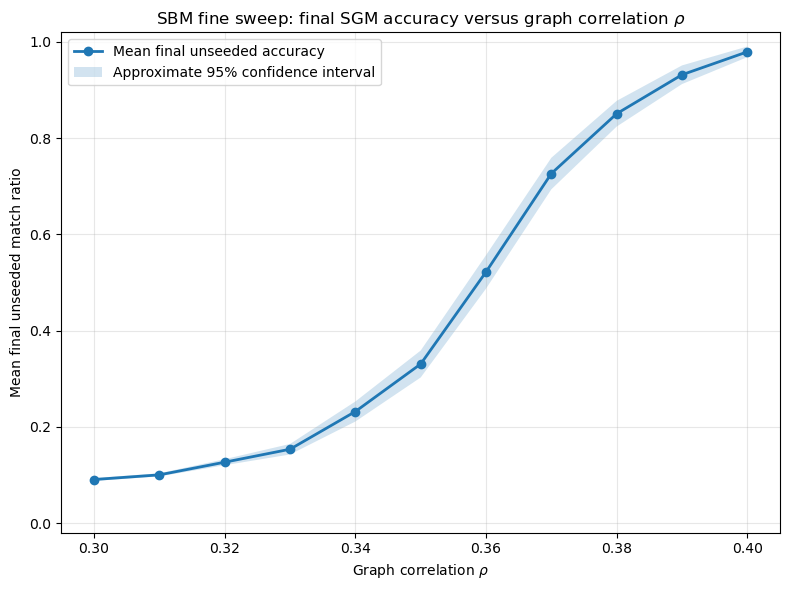

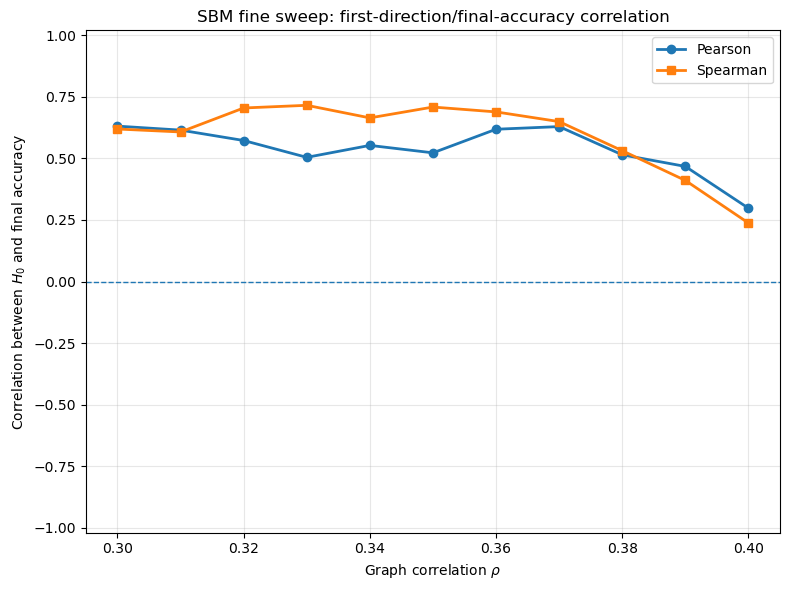

In [11]:
print_rho_sweep_summary(sbm_sweep_fine)

plot_rho_sweep_figures(sbm_sweep_fine)

In [13]:
import inspect

print(inspect.signature(gen_correlated_powerlaw_graphs))
print(inspect.getsource(gen_correlated_powerlaw_graphs))

(n=600, alpha=2.5, rho=0.8, directed=False, loops=False)
def gen_correlated_powerlaw_graphs(n=N_PL_NODES, alpha=ALPHA, rho=PL_RHO, directed=False, loops=False):
    """
    Generates a pair of correlated power-law graphs with a specified correlation rho.
    """
    # 1. Generate a power-law sequence for expected node degrees
    # Add 2 to avoid 0-degree nodes which can mess up matching metrics
    expected_degrees = np.random.pareto(alpha, size=n) + 2
    
    # 2. Scale expected degrees so they form valid probabilities when multiplied
    # P(edge i-j) = (d_i * d_j) / sum(d)
    sum_deg = np.sum(expected_degrees)
    max_deg = np.max(expected_degrees)
    
    # Check to ensure the max probability won't exceed 1.0
    if (max_deg ** 2) / sum_deg > 1.0:
        expected_degrees = expected_degrees * (np.sqrt(sum_deg) / max_deg) * 0.95
    
    # Extract the probability matrix from the expected degree layout
    # For a given node pair, probability = (d_i * d_j) / sum(d)
    deg_matrix

In [15]:
powerlaw_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

powerlaw_sweep = run_random_rho_sweep(
    graph_gen_func=gen_correlated_powerlaw_graphs,
    rho_values=powerlaw_rho_values,
    graph_kwargs={
        "n": 300,
        "alpha": 2.5,
        "directed": False,
        "loops": False,
    },
    graph_name="Power-law",
    n_seeds=20,
    n_trials=500,
    save_filename="powerlaw_random_500_trials.pkl",
)


Power-law: rho=0.10 (1/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0112
Standard deviation of H0:     0.0062
Mean final unseeded ratio:   0.0103
Std. final unseeded ratio:   0.0061
Mean final all-vertex ratio: 0.0763
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5401
Spearman(H0, final):         0.5201
Saved progress to: powerlaw_random_500_trials.pkl

Power-law: rho=0.20 (2/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0183
Standard deviation of H0:     0.0086
Mean final unseeded ratio:   0.0177
Std. final unseeded ratio:   0.0084
Mean final all-vertex ratio: 0.0832
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5999
Spearman(H0, final):         0.5711
Saved progress to: powerlaw_random_500_trials.pkl

Power-law: rho=0.30 (3/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0266
Standard deviation of H0:     0.0094
Mean final

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.10      0.0112        0.0103      0.0061     0.0000      0.5401      0.5201
  0.20      0.0183        0.0177      0.0084     0.0000      0.5999      0.5711
  0.30      0.0266        0.0274      0.0114     0.0000      0.6174      0.6068
  0.40      0.0354        0.0391      0.0150     0.0000      0.6137      0.5947
  0.50      0.0465        0.0581      0.0208     0.0000      0.7155      0.6905
  0.60      0.0588        0.0859      0.0306     0.0000      0.7168      0.7113
  0.70      0.0772        0.1440      0.0513     0.0000      0.7377      0.7386
  0.80      0.0979        0.2419      0.0946     0.0000      0.7717      0.7471


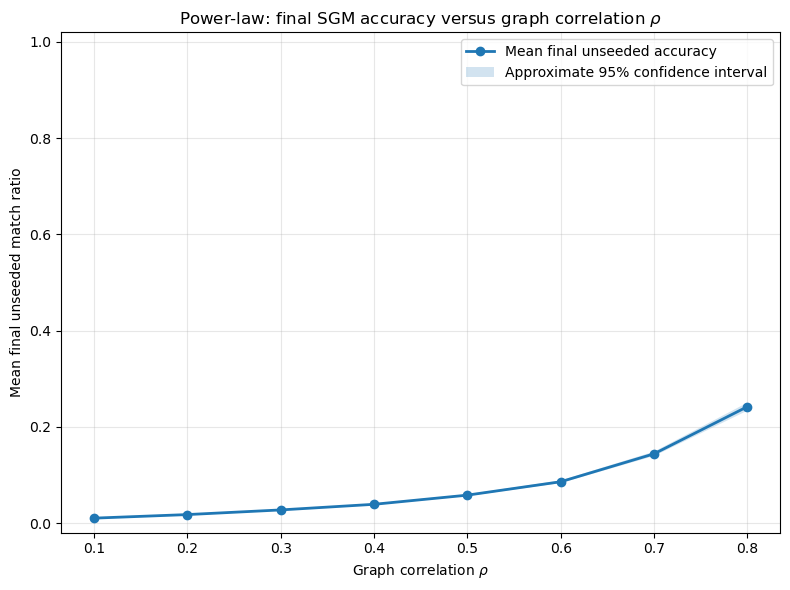

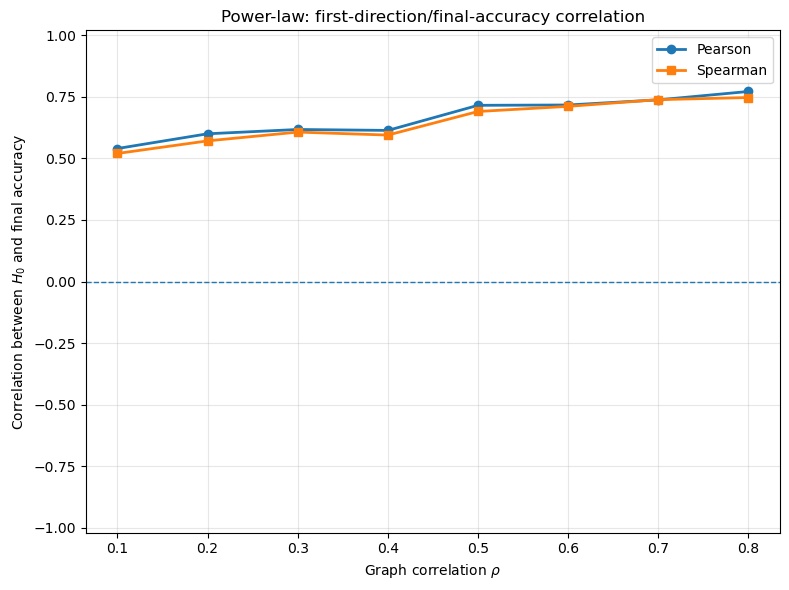

In [19]:
print_rho_sweep_summary(powerlaw_sweep)

plot_rho_sweep_figures(powerlaw_sweep)

In [21]:
powerlaw_rho_values_high = np.array([
    0.85,
    0.90,
    0.95,
    0.98,
])

powerlaw_sweep_high = run_random_rho_sweep(
    graph_gen_func=gen_correlated_powerlaw_graphs,
    rho_values=powerlaw_rho_values_high,
    graph_kwargs={
        "n": 300,
        "alpha": 2.5,
        "directed": False,
        "loops": False,
    },
    graph_name="Power-law high-rho sweep",
    n_seeds=20,
    n_trials=500,
    save_filename="powerlaw_random_high_500_trials.pkl",
)


Power-law high-rho sweep: rho=0.85 (1/4)

Summary
-------
Trials:                       500
Mean H0:                      0.1098
Standard deviation of H0:     0.0211
Mean final unseeded ratio:   0.3370
Std. final unseeded ratio:   0.1368
Mean final all-vertex ratio: 0.3812
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6841
Spearman(H0, final):         0.7079
Saved progress to: powerlaw_random_high_500_trials.pkl

Power-law high-rho sweep: rho=0.90 (2/4)

Summary
-------
Trials:                       500
Mean H0:                      0.1254
Standard deviation of H0:     0.0242
Mean final unseeded ratio:   0.4887
Std. final unseeded ratio:   0.1843
Mean final all-vertex ratio: 0.5228
Mean alpha0:                  0.0000
Pearson(H0, final):          0.7061
Spearman(H0, final):         0.6629
Saved progress to: powerlaw_random_high_500_trials.pkl

Power-law high-rho sweep: rho=0.95 (3/4)

Summary
-------
Trials:                       500
Mean H0:                     

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.85      0.1098        0.3370      0.1368     0.0000      0.6841      0.7079
  0.90      0.1254        0.4887      0.1843     0.0000      0.7061      0.6629
  0.95      0.1432        0.6599      0.1749     0.0000      0.6511      0.5711
  0.98      0.1572        0.7525      0.1480     0.0000      0.6062      0.4800


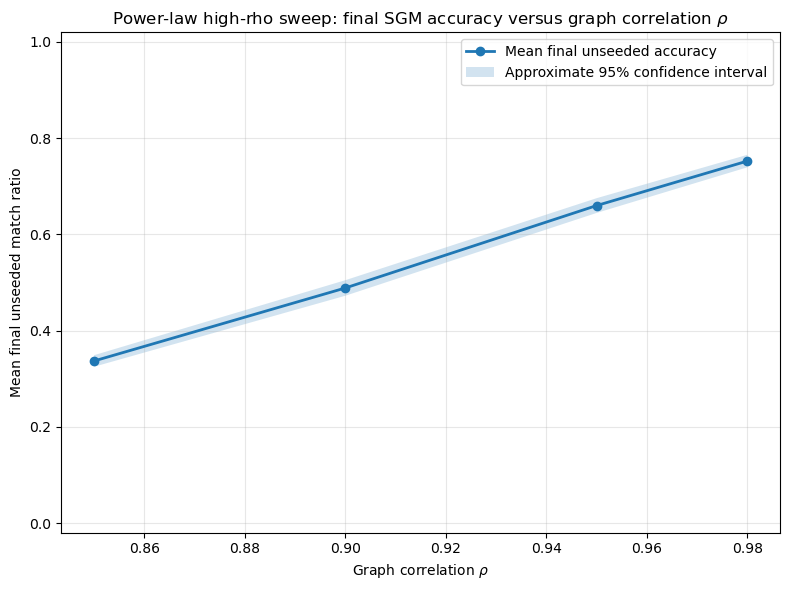

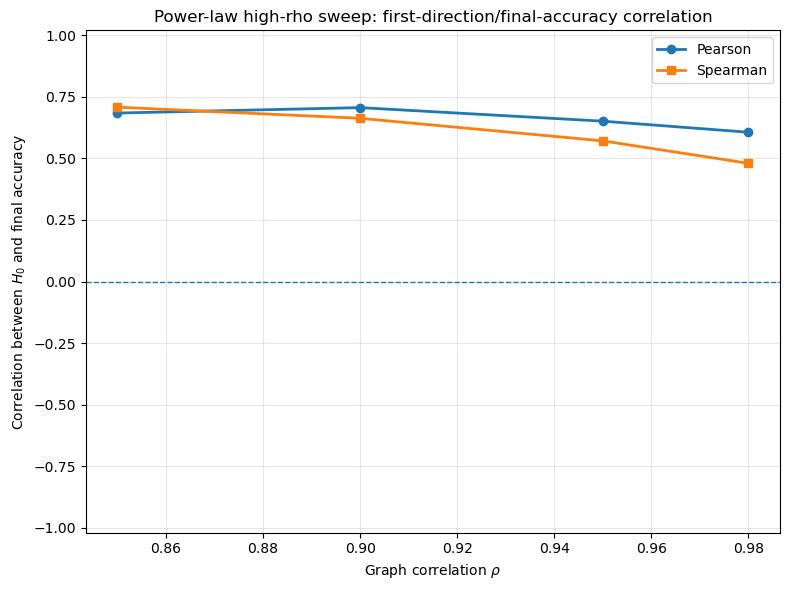

In [23]:
print_rho_sweep_summary(powerlaw_sweep_high)

plot_rho_sweep_figures(powerlaw_sweep_high)

In [25]:
import inspect

print(inspect.signature(gen_PAPER_graphs))
print(inspect.getsource(gen_PAPER_graphs))

(n=600, alpha=2.5, p=0.01, rho=0.8, directed=False, loops=False)
def gen_PAPER_graphs(n=N_PPR_NODES, alpha=PPR_ALPHA, p=PPR_EDGE_PROBABILITY, rho=PL_RHO, directed=False, loops=False):
    """
    Generates a pair of correlated power-law graphs with a specified correlation rho.
    """
    # 1. Generate a power-law sequence for expected node degrees
    # Add 2 to avoid 0-degree nodes which can mess up matching metrics
    expected_degrees = np.random.pareto(alpha, size=n) + 2
    
    # 2. Scale expected degrees so they form valid probabilities when multiplied
    # P(edge i-j) = (d_i * d_j) / sum(d)
    sum_deg = np.sum(expected_degrees)
    max_deg = np.max(expected_degrees)
    
    # Check to ensure the max probability won't exceed 1.0
    if (max_deg ** 2) / sum_deg > 1.0:
        expected_degrees = expected_degrees * (np.sqrt(sum_deg) / max_deg) * 0.95
    
    # Extract the probability matrix from the expected degree layout
    # For a given node pair, probability = (d_i * d_j) 

In [27]:
paper_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

paper_sweep = run_random_rho_sweep(
    graph_gen_func=gen_PAPER_graphs,
    rho_values=paper_rho_values,
    graph_kwargs={
        "n": 300,
        "alpha": 2.5,
        "p": 0.01,
        "directed": False,
        "loops": False,
    },
    graph_name="PAPER",
    n_seeds=20,
    n_trials=500,
    save_filename="paper_random_500_trials.pkl",
)


PAPER: rho=0.10 (1/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0116
Standard deviation of H0:     0.0062
Mean final unseeded ratio:   0.0094
Std. final unseeded ratio:   0.0059
Mean final all-vertex ratio: 0.0754
Mean alpha0:                  0.0000
Pearson(H0, final):          0.4944
Spearman(H0, final):         0.4856
Saved progress to: paper_random_500_trials.pkl

PAPER: rho=0.20 (2/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0203
Standard deviation of H0:     0.0085
Mean final unseeded ratio:   0.0173
Std. final unseeded ratio:   0.0087
Mean final all-vertex ratio: 0.0828
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5152
Spearman(H0, final):         0.5046
Saved progress to: paper_random_500_trials.pkl

PAPER: rho=0.30 (3/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0313
Standard deviation of H0:     0.0100
Mean final unseeded ratio:  

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.10      0.0116        0.0094      0.0059     0.0000      0.4944      0.4856
  0.20      0.0203        0.0173      0.0087     0.0000      0.5152      0.5046
  0.30      0.0313        0.0286      0.0117     0.0000      0.5400      0.5523
  0.40      0.0453        0.0480      0.0179     0.0000      0.5905      0.5632
  0.50      0.0628        0.0876      0.0347     0.0000      0.7230      0.6945
  0.60      0.0833        0.1799      0.0898     0.0000      0.6299      0.6797
  0.70      0.1118        0.7194      0.3085     0.0080      0.5654      0.5593
  0.80      0.1500        0.9818      0.0415     0.1420      0.2063      0.0284


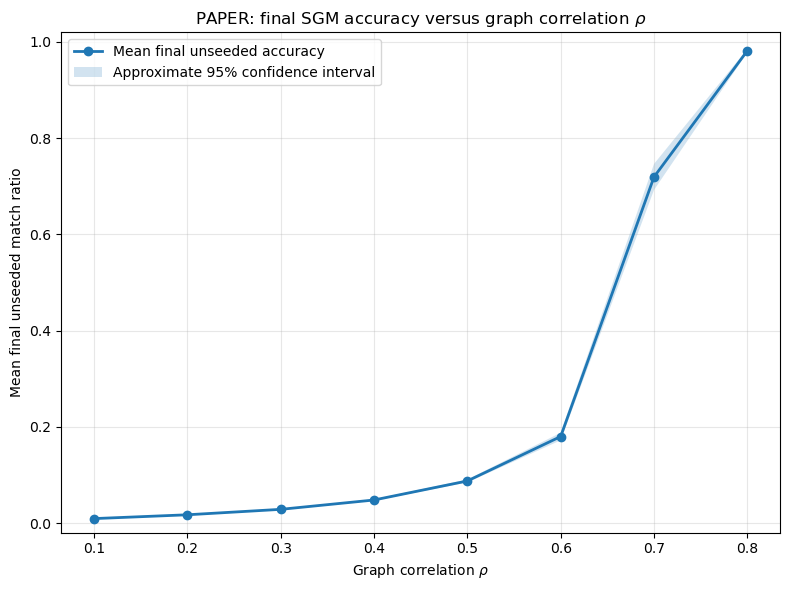

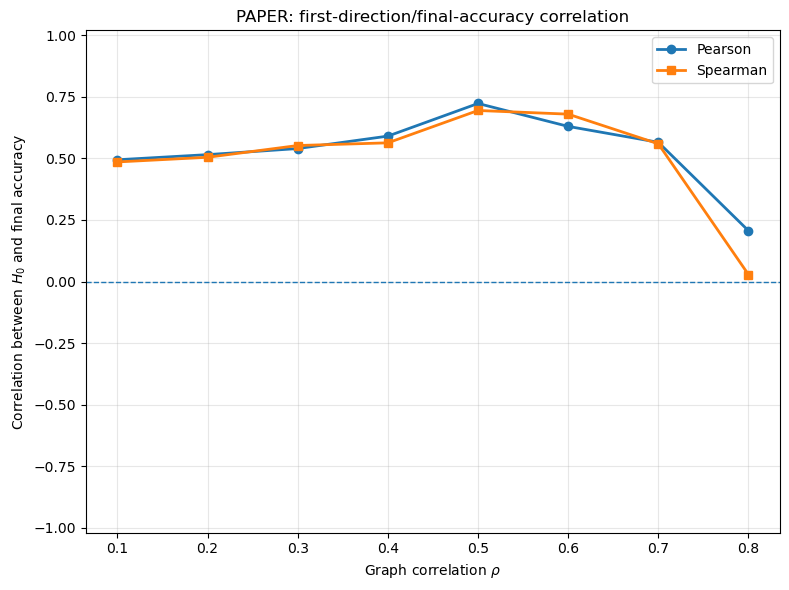

In [29]:
print_rho_sweep_summary(paper_sweep)

plot_rho_sweep_figures(paper_sweep)

In [31]:
paper_rho_values_fine = np.arange(
    0.60,
    0.801,
    0.01,
)

paper_sweep_fine = run_random_rho_sweep(
    graph_gen_func=gen_PAPER_graphs,
    rho_values=paper_rho_values_fine,
    graph_kwargs={
        "n": 300,
        "alpha": 2.5,
        "p": 0.01,
        "directed": False,
        "loops": False,
    },
    graph_name="PAPER fine sweep",
    n_seeds=20,
    n_trials=500,
    save_filename="paper_random_fine_500_trials.pkl",
)


PAPER fine sweep: rho=0.60 (1/21)

Summary
-------
Trials:                       500
Mean H0:                      0.0844
Standard deviation of H0:     0.0177
Mean final unseeded ratio:   0.1830
Std. final unseeded ratio:   0.1012
Mean final all-vertex ratio: 0.2375
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6191
Spearman(H0, final):         0.7215
Saved progress to: paper_random_fine_500_trials.pkl

PAPER fine sweep: rho=0.61 (2/21)

Summary
-------
Trials:                       500
Mean H0:                      0.0855
Standard deviation of H0:     0.0183
Mean final unseeded ratio:   0.2069
Std. final unseeded ratio:   0.1201
Mean final all-vertex ratio: 0.2598
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6531
Spearman(H0, final):         0.7547
Saved progress to: paper_random_fine_500_trials.pkl

PAPER fine sweep: rho=0.62 (3/21)

Summary
-------
Trials:                       500
Mean H0:                      0.0877
Standard deviation 

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.60      0.0844        0.1830      0.1012     0.0000      0.6191      0.7215
  0.61      0.0855        0.2069      0.1201     0.0000      0.6531      0.7547
  0.62      0.0877        0.2157      0.1237     0.0000      0.6224      0.7331
  0.63      0.0907        0.2506      0.1558     0.0000      0.6399      0.7455
  0.64      0.0928        0.2965      0.2053     0.0000      0.6506      0.7214
  0.65      0.0964        0.3474      0.2427     0.0000      0.6121      0.6653
  0.66      0.0990        0.4048      0.2710     0.0000      0.6410      0.7135
  0.67      0.1020        0.4970      0.3017     0.0040      0.6288      0.6647
  0.68      0.1040        0.5456      0.3233     0.0040      0.6314      0.6627
  0.69      0.1070        0.6076      0.3302     0.0060      0.6600      0.6589
  0.70      0.1102        0.6980      0.

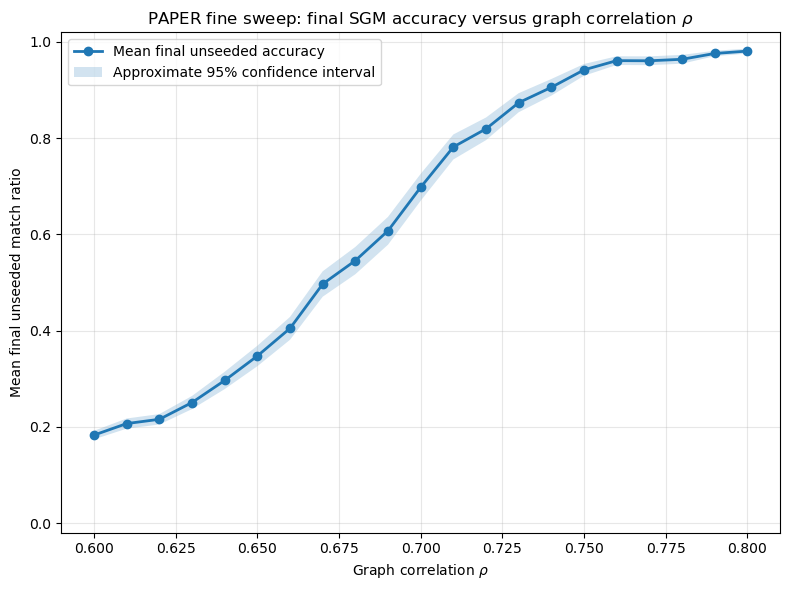

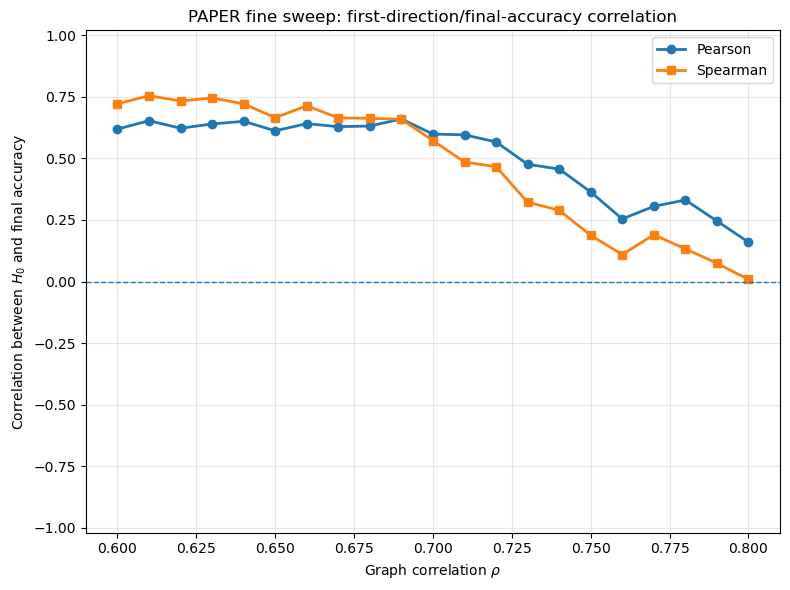

In [33]:
print_rho_sweep_summary(paper_sweep_fine)

plot_rho_sweep_figures(paper_sweep_fine)

In [35]:
er_rho_values = np.arange(
    0.10,
    0.61,
    0.05,
)

er_sweep_random = run_random_rho_sweep(
    graph_gen_func=gen_ER_graphs,
    rho_values=er_rho_values,
    graph_kwargs={
        "n": 300,
        "p": 0.2,
    },
    graph_name="ER",
    n_seeds=20,
    n_trials=500,
    save_filename="er_random_500_trials.pkl",
)


ER: rho=0.10 (1/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0115
Standard deviation of H0:     0.0064
Mean final unseeded ratio:   0.0072
Std. final unseeded ratio:   0.0050
Mean final all-vertex ratio: 0.0734
Mean alpha0:                  0.0000
Pearson(H0, final):          0.3896
Spearman(H0, final):         0.3853
Saved progress to: er_random_500_trials.pkl

ER: rho=0.15 (2/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0193
Standard deviation of H0:     0.0084
Mean final unseeded ratio:   0.0104
Std. final unseeded ratio:   0.0065
Mean final all-vertex ratio: 0.0764
Mean alpha0:                  0.0000
Pearson(H0, final):          0.4645
Spearman(H0, final):         0.4499
Saved progress to: er_random_500_trials.pkl

ER: rho=0.20 (3/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0310
Standard deviation of H0:     0.0105
Mean final unseeded ratio:   0.0156
Std.

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.10      0.0115        0.0072      0.0050     0.0000      0.3896      0.3853
  0.15      0.0193        0.0104      0.0065     0.0000      0.4645      0.4499
  0.20      0.0310        0.0156      0.0082     0.0000      0.4748      0.4584
  0.25      0.0454        0.0238      0.0103     0.0000      0.4781      0.4494
  0.30      0.0674        0.0393      0.0160     0.0000      0.6299      0.5996
  0.35      0.0970        0.0772      0.0325     0.0000      0.7020      0.6984
  0.40      0.1333        0.5036      0.4079     0.3980      0.6962      0.7720
  0.45      0.1793        0.9991      0.0209     0.9980      0.1315      0.0775
  0.50      0.2364        1.0000      0.0000     1.0000         nan         nan
  0.55      0.3053        1.0000      0.0000     1.0000         nan         nan
  0.60      0.3878        1.0000      0.

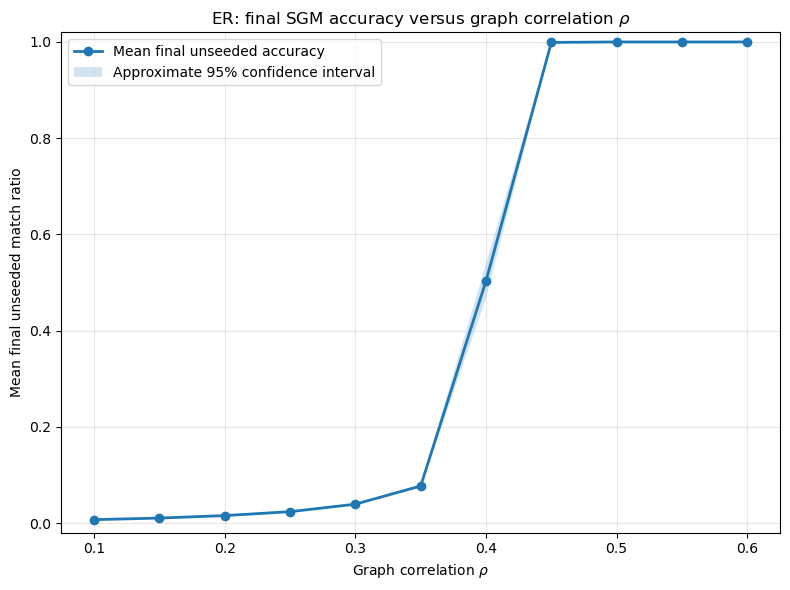

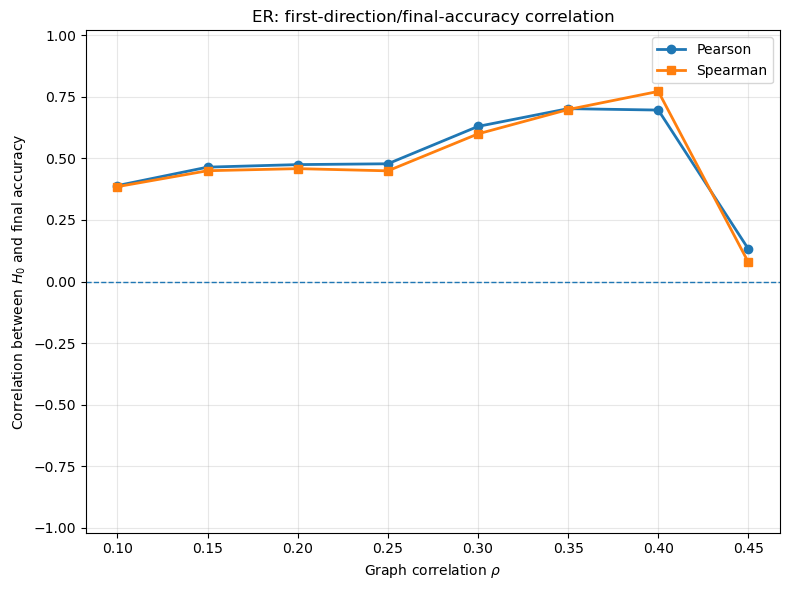

In [37]:
print_rho_sweep_summary(er_sweep_random)

plot_rho_sweep_figures(er_sweep_random)

In [39]:
er_rho_values_fine = np.arange(
    0.35,
    0.451,
    0.01,
)

er_sweep_fine = run_random_rho_sweep(
    graph_gen_func=gen_ER_graphs,
    rho_values=er_rho_values_fine,
    graph_kwargs={
        "n": 300,
        "p": 0.2,
    },
    graph_name="ER fine sweep",
    n_seeds=20,
    n_trials=500,
    save_filename="er_random_fine_500_trials.pkl",
)


ER fine sweep: rho=0.35 (1/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0953
Standard deviation of H0:     0.0192
Mean final unseeded ratio:   0.0780
Std. final unseeded ratio:   0.0345
Mean final all-vertex ratio: 0.1395
Mean alpha0:                  0.0000
Pearson(H0, final):          0.7368
Spearman(H0, final):         0.7491
Saved progress to: er_random_fine_500_trials.pkl

ER fine sweep: rho=0.36 (2/11)

Summary
-------
Trials:                       500
Mean H0:                      0.1017
Standard deviation of H0:     0.0196
Mean final unseeded ratio:   0.0921
Std. final unseeded ratio:   0.0581
Mean final all-vertex ratio: 0.1527
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5950
Spearman(H0, final):         0.6960
Saved progress to: er_random_fine_500_trials.pkl

ER fine sweep: rho=0.37 (3/11)

Summary
-------
Trials:                       500
Mean H0:                      0.1072
Standard deviation of H0:     0.01

   rho     Mean H0    Mean final   Std final    Perfect     Pearson    Spearman
-------------------------------------------------------------------------------
  0.35      0.0953        0.0780      0.0345     0.0000      0.7368      0.7491
  0.36      0.1017        0.0921      0.0581     0.0020      0.5950      0.6960
  0.37      0.1072        0.1217      0.1263     0.0160      0.4786      0.6941
  0.38      0.1147        0.1800      0.2143     0.0540      0.5577      0.7645
  0.39      0.1245        0.2961      0.3216     0.1660      0.6431      0.7698
  0.40      0.1328        0.4950      0.4071     0.3880      0.7031      0.7709
  0.41      0.1401        0.6757      0.4038     0.6000      0.6334      0.6671
  0.42      0.1504        0.8573      0.3055     0.8180      0.5031      0.5203
  0.43      0.1583        0.9470      0.2001     0.9300      0.4659      0.4093
  0.44      0.1688        0.9806      0.1238     0.9760      0.3113      0.2536
  0.45      0.1795        0.9950      0.

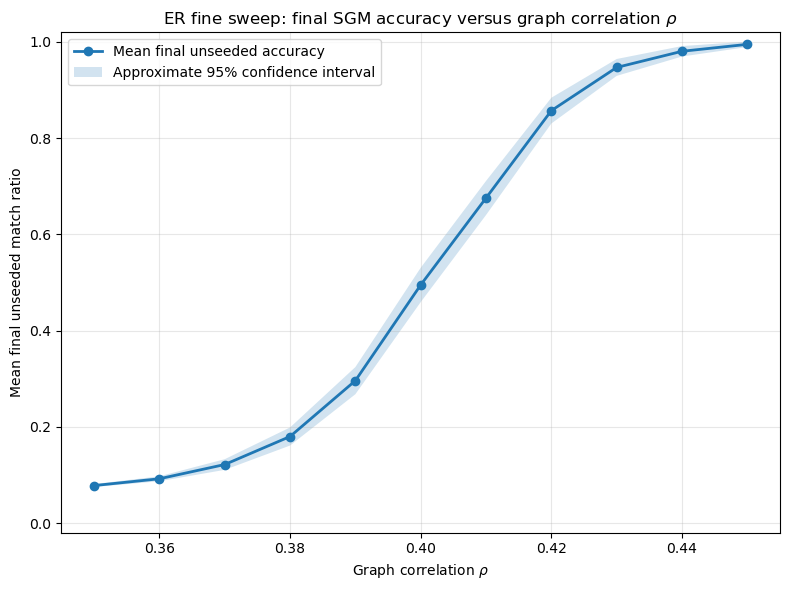

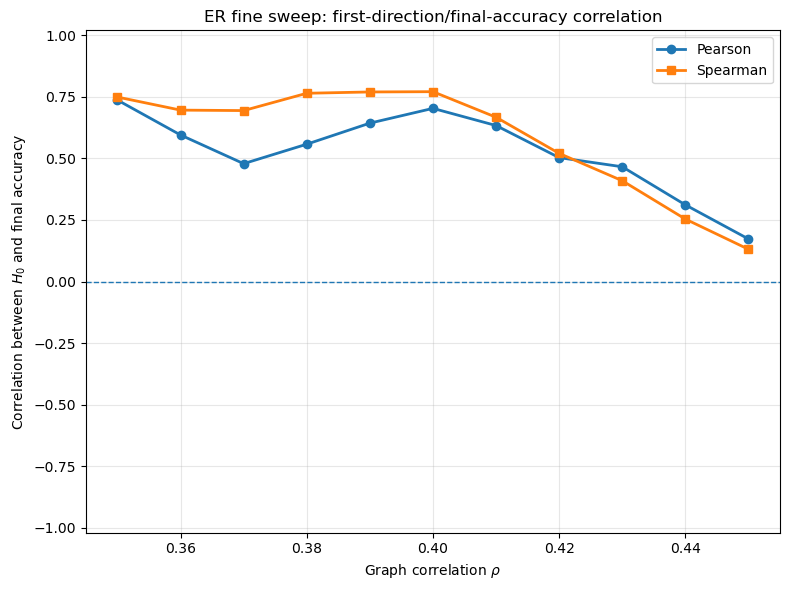

In [42]:
print_rho_sweep_summary(er_sweep_fine)

plot_rho_sweep_figures(er_sweep_fine)

In [44]:
def inspect_alpha0_sweep(sweep_results):
    for rho in sweep_results["rho_values"]:
        records = sweep_results["records_by_rho"][float(rho)]

        alpha0 = np.array(
            [record["alpha0"] for record in records],
            dtype=float,
        )

        print(
            f"rho={rho:.2f}: "
            f"min={alpha0.min():.17g}, "
            f"max={alpha0.max():.17g}, "
            f"mean={alpha0.mean():.17g}, "
            f"exactly_zero={np.sum(alpha0 == 0.0)}/{len(alpha0)}"
        )

In [46]:
inspect_alpha0_sweep(er_sweep_fine)

rho=0.35: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.36: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.37: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.38: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.39: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.40: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.41: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.42: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.43: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.44: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.45: min=0, max=0, mean=0, exactly_zero=500/500


In [48]:
import inspect

print(
    inspect.getsource(
        wrappers._GraphMatchSolver.compute_step_size
    )
)

    @write_status("Computing step size", 2)
    def compute_step_size(self, P: np.ndarray, Q: np.ndarray) -> float:
        a, b = _compute_coefficients(
            P,
            Q,
            self.A_nn,
            self.B_nn,
            self.AB_nn,
            self.BA_nn,
            self.A_ns,
            self.A_sn,
            self.B_ns,
            self.B_sn,
            self.AB_ns,
            self.AB_sn,
            self.BA_ns,
            self.BA_sn,
            self.S_nn,
            fast=self.fast,
        )
        if a * self.obj_func_scalar > 0 and 0 <= -b / (2 * a) <= 1:
            alpha = -b / (2 * a)
        else:
            alpha = float(np.argmin([0, (b + a) * self.obj_func_scalar]))
        return alpha



In [50]:
def diagnose_full_alpha_history_er(
    rho=0.40,
    n=300,
    p=0.2,
    n_seeds=20,
    n_trials=20,
):
    alpha_histories = []

    for trial in range(n_trials):
        G1, G2, true_perm = gen_ER_graphs(
            n=n,
            p=p,
            rho=rho,
        )

        true_perm = np.asarray(true_perm, dtype=int)

        seeds_G1, seeds_G2 = random_seeds(
            G1,
            G2,
            n_seeds,
            true_perm,
        )

        partial_match = np.column_stack(
            (seeds_G1, seeds_G2)
        )

        graph_match(
            G1,
            G2,
            partial_match=partial_match,
            rng=int(np.random.randint(0, 2**32)),
        )

        alpha_histories.append(
            np.array(
                last_solver.alpha_history_,
                dtype=float,
            )
        )

    for trial, history in enumerate(
        alpha_histories,
        start=1,
    ):
        print(
            f"Trial {trial:>2}: "
            f"iterations={len(history)}, "
            f"alphas={history}"
        )

    return alpha_histories

In [52]:
er_alpha_histories = diagnose_full_alpha_history_er(
    rho=0.40,
    n_trials=20,
)

Trial  1: iterations=30, alphas=[0.         0.62840565 0.38787334 0.49094394 0.39256044 0.50373992
 0.14463758 0.60433572 0.         0.67674419 0.         0.69827586
 0.         0.75       0.         0.74712644 0.         0.67424242
 0.         0.828125   0.1891253  0.15290179 0.6619594  0.
 0.66666667 0.         0.5        0.         0.875      0.84      ]
Trial  2: iterations=30, alphas=[0.         0.59621993 0.35584834 0.51275575 0.35390456 0.40956076
 0.37255619 0.52496226 0.         0.6763285  0.         0.81012658
 0.1714123  0.7515486  0.20216774 0.70768029 0.         0.81176471
 0.         0.84210526 0.         0.78333333 0.00319489 0.68127464
 0.         0.4        0.125      0.735363   0.         0.        ]
Trial  3: iterations=11, alphas=[0.         0.60506667 0.30413093 0.50198945 0.20841934 0.58309178
 0.         0.48841699 0.         0.         0.        ]
Trial  4: iterations=29, alphas=[0.         0.61986132 0.27723034 0.47612619 0.0039904  0.59169326
 0.         0.662

In [54]:
def summarize_alpha0_sweep(sweep_results, sweep_name):
    """
    Inspect alpha0 across every rho in one saved rho-sweep.
    """
    total_trials = 0
    total_zero = 0
    global_min = np.inf
    global_max = -np.inf

    print("\n" + "=" * 85)
    print(sweep_name)
    print("=" * 85)

    for rho in sweep_results["rho_values"]:
        records = sweep_results["records_by_rho"][float(rho)]

        alpha0 = np.array(
            [record["alpha0"] for record in records],
            dtype=float,
        )

        n_zero = int(np.sum(alpha0 == 0.0))

        total_trials += len(alpha0)
        total_zero += n_zero
        global_min = min(global_min, float(alpha0.min()))
        global_max = max(global_max, float(alpha0.max()))

        print(
            f"rho={rho:.2f}: "
            f"min={alpha0.min():.17g}, "
            f"max={alpha0.max():.17g}, "
            f"mean={alpha0.mean():.17g}, "
            f"exactly_zero={n_zero}/{len(alpha0)}"
        )

    print("-" * 85)
    print(f"Overall exactly zero: {total_zero}/{total_trials}")
    print(f"Overall minimum:      {global_min:.17g}")
    print(f"Overall maximum:      {global_max:.17g}")

    return {
        "sweep": sweep_name,
        "n_trials": total_trials,
        "n_exactly_zero": total_zero,
        "fraction_exactly_zero": total_zero / total_trials,
        "minimum": global_min,
        "maximum": global_max,
    }

In [56]:
alpha_summaries = []

sweeps_to_check = [
    ("ER coarse", er_sweep_random),
    ("ER fine", er_sweep_fine),
    ("SBM coarse", sbm_sweep),
    ("SBM fine", sbm_sweep_fine),
    ("Power-law coarse", powerlaw_sweep),
    ("Power-law high rho", powerlaw_sweep_high),
    ("PAPER coarse", paper_sweep),
    ("PAPER fine", paper_sweep_fine),
]

for sweep_name, sweep_results in sweeps_to_check:
    alpha_summaries.append(
        summarize_alpha0_sweep(
            sweep_results,
            sweep_name,
        )
    )


ER coarse
rho=0.10: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.15: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.20: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.25: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.30: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.35: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.40: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.45: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.50: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.55: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.60: min=0, max=0, mean=0, exactly_zero=500/500
-------------------------------------------------------------------------------------
Overall exactly zero: 5500/5500
Overall minimum:      0
Overall maximum:      0

ER fine
rho=0.35: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.36: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.37: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.38: min=0, max=0, mean=0, exactly_zero=500/500
rho=0.39: min=0, ma

In [58]:
grand_total = sum(
    result["n_trials"]
    for result in alpha_summaries
)

grand_zero = sum(
    result["n_exactly_zero"]
    for result in alpha_summaries
)

print("\nOVERALL ALPHA0 RESULT")
print("---------------------")
print(f"Exactly zero: {grand_zero}/{grand_total}")
print(f"Fraction zero: {grand_zero / grand_total:.8f}")


OVERALL ALPHA0 RESULT
---------------------
Exactly zero: 41000/41000
Fraction zero: 1.00000000


In [1]:
import inspect
import graspologic
import graspologic.match.wrappers as wrappers

print("graspologic version:", graspologic.__version__)
print("wrappers file:", inspect.getfile(wrappers))

print("\n_compute_coefficients source:\n")
print(inspect.getsource(wrappers._GraphMatchSolver.compute_step_size.__globals__["_compute_coefficients"]))

graspologic version: 3.4.4
wrappers file: /Applications/anaconda3/lib/python3.12/site-packages/graspologic/match/wrappers.py

_compute_coefficients source:



AttributeError: module 'graspologic.match.wrappers' has no attribute '_compute_coefficients'

In [3]:
import inspect
from graspologic.match.wrappers import _GraphMatchSolver

print(inspect.getsource(wrappers._GraphMatchSolver.compute_step_size.__globals__["_compute_coefficients"]))

AttributeError: type object '_GraphMatchSolver' has no attribute '_compute_coefficients'

In [5]:
import inspect

print(inspect.getsource(wrappers._GraphMatchSolver.compute_step_size.__globals__["_compute_coefficients"]))

NameError: name 'last_solver' is not defined

In [11]:
import inspect
from graspologic.match.wrappers import _GraphMatchSolver

for name, obj in inspect.getmembers(_GraphMatchSolver):
    if "coeff" in name.lower():
        print(name)

In [9]:
for name, obj in inspect.getmembers(_GraphMatchSolver):
    if inspect.isfunction(obj):
        print(name)

__init__
check_converged
compute_constant_terms
compute_gradient
compute_score
compute_step_direction
compute_step_size
finalize
initialize
linear_sum_assignment
linear_sum_transport
solve
status


In [13]:
import inspect
from graspologic.match.wrappers import _GraphMatchSolver

print(inspect.getsource(_GraphMatchSolver.compute_step_size))

    @write_status("Computing step size", 2)
    def compute_step_size(self, P: np.ndarray, Q: np.ndarray) -> float:
        a, b = _compute_coefficients(
            P,
            Q,
            self.A_nn,
            self.B_nn,
            self.AB_nn,
            self.BA_nn,
            self.A_ns,
            self.A_sn,
            self.B_ns,
            self.B_sn,
            self.AB_ns,
            self.AB_sn,
            self.BA_ns,
            self.BA_sn,
            self.S_nn,
            fast=self.fast,
        )
        if a * self.obj_func_scalar > 0 and 0 <= -b / (2 * a) <= 1:
            alpha = -b / (2 * a)
        else:
            alpha = float(np.argmin([0, (b + a) * self.obj_func_scalar]))
        return alpha



In [15]:
print(inspect.getsource(_GraphMatchSolver.compute_gradient))
print(inspect.getsource(_GraphMatchSolver.compute_step_direction))
print(inspect.getsource(_GraphMatchSolver.compute_step_size))

    @write_status("Computing gradient", 2)
    def compute_gradient(self, P: np.ndarray) -> np.ndarray:
        gradient = _compute_gradient(
            P, self.A_nn, self.B_nn, self.AB_nn, self.BA_nn, self.constant_sum
        )
        return gradient

    @write_status("Solving assignment problem", 2)
    def compute_step_direction(
        self, gradient: np.ndarray, rng: np.random.Generator
    ) -> np.ndarray:
        # [1] Algorithm 1 Line 4 - get direction Q by solving Eq. 8
        if self.transport:
            Q = self.linear_sum_transport(gradient)
        else:
            permutation = self.linear_sum_assignment(gradient, rng)
            Q = np.eye(self.n_unseed)[permutation]
        return Q

    @write_status("Computing step size", 2)
    def compute_step_size(self, P: np.ndarray, Q: np.ndarray) -> float:
        a, b = _compute_coefficients(
            P,
            Q,
            self.A_nn,
            self.B_nn,
            self.AB_nn,
            self.BA_nn,
   

In [17]:
import inspect
from graspologic.match.wrappers import _GraphMatchSolver

compute_coefficients = (
    _GraphMatchSolver.compute_step_size.__globals__["_compute_coefficients"]
)

print("Function module:", compute_coefficients.__module__)
print("Function file:", inspect.getfile(compute_coefficients))
print("\nSource:\n")
print(inspect.getsource(compute_coefficients))

Function module: graspologic.match.solver
Function file: /Applications/anaconda3/lib/python3.12/site-packages/graspologic/match/solver.py

Source:

def _compute_coefficients(
    P: np.ndarray,
    Q: np.ndarray,
    A: MultilayerAdjacency,
    B: MultilayerAdjacency,
    AB: MultilayerAdjacency,
    BA: MultilayerAdjacency,
    A_ns: MultilayerAdjacency,
    A_sn: MultilayerAdjacency,
    B_ns: MultilayerAdjacency,
    B_sn: MultilayerAdjacency,
    AB_ns: MultilayerAdjacency,
    AB_sn: MultilayerAdjacency,
    BA_ns: MultilayerAdjacency,
    BA_sn: MultilayerAdjacency,
    S: AdjacencyMatrix,
    fast: bool,
) -> Tuple[float, float]:
    R = P - Q

    n_layers = len(A)
    a_cross = 0.0
    b_cross = 0.0
    a_intra = 0.0
    b_intra = 0.0

    for i in range(n_layers):
        if fast:
            # could maybe be even faster if we do `opt_einsum` or something
            ABiTR = AB[i].T @ R
            BAiR = BA[i] @ R
            AiR = A[i] @ R
            RBi = R @ B[i]

      

In [21]:
print(inspect.getsource(_GraphMatchSolver.compute_score))

    def compute_score(self, permutation: np.ndarray) -> float:
        score = 0.0
        n_layers = self.n_layers
        for layer in range(n_layers):
            # casting explicitly to float here because mypy was yelling:
            # 'Incompatible types in assignment (expression has type "floating[Any]",
            # variable has type "float")'
            score += np.sum(self.A[layer] * self.B[layer][permutation][:, permutation])
            score += np.sum(
                self.AB[layer][:, permutation] * self.BA[layer][permutation]
            )
            # for some reason, trace was not working on Py 3.7
            # this is equivalent to trace(SP^T)
            score += float(np.sum(self.S[np.arange(self.S.shape[0]), permutation]))
        return score



In [35]:
# ============================================================
# ONE-CELL FIRST-STEP LINE-SEARCH DIAGNOSTICS
# Compatible with graspologic 3.4.4
#
# Run this cell once AFTER your original notebook setup cell.
# You do not need to edit any existing functions or cells.
# ============================================================

import numpy as np
import pandas as pd
import graspologic.match.wrappers as wrappers


# Exact private coefficient function used by graspologic 3.4.4
_compute_coefficients_exact = (
    wrappers._GraphMatchSolver
    .compute_step_size
    .__globals__["_compute_coefficients"]
)


# Every future graph_match run will append one first-step record here.
FIRST_STEP_DIAGNOSTICS = []

# Keeps access to the most recently used solver.
last_solver = None


def clear_first_step_diagnostics():
    """Clear diagnostics before starting a new experiment."""
    FIRST_STEP_DIAGNOSTICS.clear()
    print("First-step diagnostic records cleared.")


def solve_with_full_line_search_history(self, rng=None):
    """
    Notebook-only replacement for _GraphMatchSolver.solve.

    It records the exact quadratic coefficients used by graspologic:

        phi(alpha) = c + b*alpha + a*alpha^2

    along

        P(alpha) = alpha*P + (1-alpha)*Q.

    It also appends the first iteration from every graph_match call to
    FIRST_STEP_DIAGNOSTICS automatically.
    """
    global last_solver
    last_solver = self

    rng = np.random.default_rng(rng)

    self.n_iter_ = 0
    self.converged_ = False

    self.P_history_ = []
    self.Q_history_ = []
    self.alpha_history_ = []

    self.a_history_ = []
    self.b_history_ = []
    self.line_search_history_ = []

    if self.n_seeds == self.n:
        P = np.empty((0, 0))
        self.converged_ = True

    else:
        P = self.initialize(rng)
        self.P_history_.append(P.copy())

        self.compute_constant_terms()

        for iteration in range(self.max_iter):
            self.n_iter_ = iteration + 1

            gradient = self.compute_gradient(P)
            Q = self.compute_step_direction(gradient, rng)

            # Compute the exact a and b used internally by graspologic.
            a, b = _compute_coefficients_exact(
                P,
                Q,
                self.A_nn,
                self.B_nn,
                self.AB_nn,
                self.BA_nn,
                self.A_ns,
                self.A_sn,
                self.B_ns,
                self.B_sn,
                self.AB_ns,
                self.AB_sn,
                self.BA_ns,
                self.BA_sn,
                self.S_nn,
                fast=self.fast,
            )

            a = float(a)
            b = float(b)

            # Let graspologic make the actual step-size decision.
            alpha = float(self.compute_step_size(P, Q))

            obj_scalar = float(self.obj_func_scalar)

            a_plus_b = a + b
            two_a_plus_b = 2.0 * a + b

            scaled_a = obj_scalar * a
            scaled_a_plus_b = obj_scalar * a_plus_b
            scaled_two_a_plus_b = obj_scalar * two_a_plus_b

            if np.isclose(a, 0.0):
                stationary_alpha = np.nan
            else:
                stationary_alpha = -b / (2.0 * a)

            interior_candidate = bool(
                scaled_a > 0
                and np.isfinite(stationary_alpha)
                and 0.0 <= stationary_alpha <= 1.0
            )

            if np.isclose(alpha, 0.0):
                selected_location = "Q endpoint"
            elif np.isclose(alpha, 1.0):
                selected_location = "P endpoint"
            else:
                selected_location = "interior"

            diagnostic = {
                "iteration": int(iteration),
                "a": a,
                "b": b,
                "a_plus_b": a_plus_b,
                "two_a_plus_b": two_a_plus_b,
                "obj_func_scalar": obj_scalar,
                "scaled_a": scaled_a,
                "scaled_a_plus_b": scaled_a_plus_b,
                "scaled_two_a_plus_b": scaled_two_a_plus_b,
                "stationary_alpha": stationary_alpha,
                "interior_candidate": interior_candidate,
                "alpha": alpha,
                "selected_location": selected_location,
            }

            self.a_history_.append(a)
            self.b_history_.append(b)
            self.Q_history_.append(Q.copy())
            self.alpha_history_.append(alpha)
            self.line_search_history_.append(diagnostic)

            # Automatically save the first iteration of this graph_match call.
            if iteration == 0:
                first_record = diagnostic.copy()
                first_record["run_number"] = len(FIRST_STEP_DIAGNOSTICS) + 1
                first_record["n_vertices"] = int(self.n)
                first_record["n_seeds"] = int(self.n_seeds)
                FIRST_STEP_DIAGNOSTICS.append(first_record)

            P_new = alpha * P + (1.0 - alpha) * Q
            self.P_history_.append(P_new.copy())

            if self.check_converged(P, P_new):
                self.converged_ = True
                P = P_new
                break

            P = P_new

    self.finalize(P, rng)


# Install the expanded notebook-only patch.
wrappers._GraphMatchSolver.solve = solve_with_full_line_search_history


def first_step_dataframe():
    """Return all automatically collected first-step records."""
    return pd.DataFrame(FIRST_STEP_DIAGNOSTICS)


def summarize_first_step_diagnostics(show_rows=10):
    """
    Print a summary of all graph_match calls made since the diagnostics
    were last cleared.
    """
    df = first_step_dataframe()

    if df.empty:
        print(
            "No diagnostics have been recorded yet.\n"
            "Run one of your existing experiments, then call:\n"
            "summarize_first_step_diagnostics()"
        )
        return df

    tolerance = 1e-10

    alpha_zero = np.isclose(df["alpha"], 0.0, atol=tolerance)
    alpha_one = np.isclose(df["alpha"], 1.0, atol=tolerance)
    alpha_interior = ~(alpha_zero | alpha_one)

    # The exact implementation-level dangerous case:
    # a valid interior optimum under graspologic's objective convention.
    interior_condition = (
        (df["scaled_a"] > tolerance)
        & np.isfinite(df["stationary_alpha"])
        & (df["stationary_alpha"] > tolerance)
        & (df["stationary_alpha"] < 1.0 - tolerance)
    )

    print("=" * 68)
    print("FIRST-ITERATION LINE-SEARCH SUMMARY")
    print("=" * 68)
    print(f"Graph-match runs recorded:          {len(df)}")
    print(f"alpha_0 = 0  (Q endpoint):          {int(alpha_zero.sum())}")
    print(f"alpha_0 = 1  (P endpoint):          {int(alpha_one.sum())}")
    print(f"0 < alpha_0 < 1 (interior):         {int(alpha_interior.sum())}")
    print(f"Interior condition detected:        {int(interior_condition.sum())}")
    print()
    print(f"Minimum alpha_0:                    {df['alpha'].min():.12g}")
    print(f"Maximum alpha_0:                    {df['alpha'].max():.12g}")
    print(f"Minimum scaled (2a_0+b_0):          "
          f"{df['scaled_two_a_plus_b'].min():.12g}")
    print(f"Maximum scaled (2a_0+b_0):          "
          f"{df['scaled_two_a_plus_b'].max():.12g}")

    if interior_condition.any():
        print("\nWARNING: Interior first-step candidates were found:")
        display_columns = [
            "run_number",
            "n_vertices",
            "n_seeds",
            "a",
            "b",
            "scaled_a",
            "stationary_alpha",
            "alpha",
            "selected_location",
        ]
        print(
            df.loc[interior_condition, display_columns]
            .to_string(index=False)
        )
    else:
        print(
            "\nNo strict interior first-step condition was found."
        )

    print(f"\nFirst {min(show_rows, len(df))} records:")
    display_columns = [
        "run_number",
        "n_vertices",
        "n_seeds",
        "a",
        "b",
        "a_plus_b",
        "two_a_plus_b",
        "stationary_alpha",
        "alpha",
        "selected_location",
    ]
    print(df[display_columns].head(show_rows).to_string(index=False))

    return df


print("Full line-search diagnostic patch installed.")
print()
print("Next:")
print("1. Run: clear_first_step_diagnostics()")
print("2. Run any of your existing experiment cells normally.")
print("3. Run: diagnostics_df = summarize_first_step_diagnostics()")

Full line-search diagnostic patch installed.

Next:
1. Run: clear_first_step_diagnostics()
2. Run any of your existing experiment cells normally.
3. Run: diagnostics_df = summarize_first_step_diagnostics()


In [37]:
clear_first_step_diagnostics()

First-step diagnostic records cleared.


In [39]:
sbm_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

sbm_block_probs = np.array(
    [
        [0.3, 0.1, 0.1],
        [0.1, 0.3, 0.1],
        [0.1, 0.1, 0.3],
    ]
)

sbm_sweep = run_random_rho_sweep(
    graph_gen_func=gen_SBM_graphs,
    rho_values=sbm_rho_values,
    graph_kwargs={
        "directed": False,
        "loops": False,
        "n_per_block": 100,
        "n_blocks": 3,
        "block_probs": sbm_block_probs,
    },
    graph_name="SBM",
    n_seeds=20,
    n_trials=5,
    save_filename="sbm_random_5_trials_diagnostic.pkl",
)


SBM: rho=0.10 (1/8)

Summary
-------
Trials:                       5
Mean H0:                      0.0186
Standard deviation of H0:     0.0052
Mean final unseeded ratio:   0.0164
Std. final unseeded ratio:   0.0086
Mean final all-vertex ratio: 0.0820
Mean alpha0:                  0.0000
Pearson(H0, final):          0.8109
Spearman(H0, final):         0.8721
Saved progress to: sbm_random_5_trials_diagnostic.pkl

SBM: rho=0.20 (2/8)

Summary
-------
Trials:                       5
Mean H0:                      0.0357
Standard deviation of H0:     0.0090
Mean final unseeded ratio:   0.0414
Std. final unseeded ratio:   0.0119
Mean final all-vertex ratio: 0.1053
Mean alpha0:                  0.0000
Pearson(H0, final):          0.7614
Spearman(H0, final):         0.5000
Saved progress to: sbm_random_5_trials_diagnostic.pkl

SBM: rho=0.30 (3/8)

Summary
-------
Trials:                       5
Mean H0:                      0.0779
Standard deviation of H0:     0.0118
Mean final unseeded ratio:

In [41]:
print(run_random_rho_sweep)
print(gen_SBM_graphs)

<function run_random_rho_sweep at 0x179de2f20>
<function gen_SBM_graphs at 0x1799402c0>


In [43]:
diagnostics_df = summarize_first_step_diagnostics()

FIRST-ITERATION LINE-SEARCH SUMMARY
Graph-match runs recorded:          40
alpha_0 = 0  (Q endpoint):          40
alpha_0 = 1  (P endpoint):          0
0 < alpha_0 < 1 (interior):         0
Interior condition detected:        0

Minimum alpha_0:                    0
Maximum alpha_0:                    0
Minimum scaled (2a_0+b_0):          1057.73836735
Maximum scaled (2a_0+b_0):          1389.83183673

No strict interior first-step condition was found.

First 10 records:
 run_number  n_vertices  n_seeds          a            b     a_plus_b  two_a_plus_b  stationary_alpha  alpha selected_location
          1         300       20 137.553469 -1388.592857 -1251.039388  -1113.485918          5.047466    0.0        Q endpoint
          2         300       20 108.850000 -1301.085714 -1192.235714  -1083.385714          5.976508    0.0        Q endpoint
          3         300       20  91.164286 -1275.564286 -1184.400000  -1093.235714          6.995965    0.0        Q endpoint
          4     

In [45]:
clear_first_step_diagnostics()

First-step diagnostic records cleared.


In [47]:
sbm_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

sbm_block_probs = np.array(
    [
        [0.3, 0.1, 0.1],
        [0.1, 0.3, 0.1],
        [0.1, 0.1, 0.3],
    ]
)

sbm_sweep = run_random_rho_sweep(
    graph_gen_func=gen_SBM_graphs,
    rho_values=sbm_rho_values,
    graph_kwargs={
        "directed": False,
        "loops": False,
        "n_per_block": 100,
        "n_blocks": 3,
        "block_probs": sbm_block_probs,
    },
    graph_name="SBM",
    n_seeds=20,
    n_trials=500,
    save_filename="sbm_random_500_trials_diagnostic.pkl",
)


SBM: rho=0.10 (1/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0173
Standard deviation of H0:     0.0079
Mean final unseeded ratio:   0.0182
Std. final unseeded ratio:   0.0087
Mean final all-vertex ratio: 0.0836
Mean alpha0:                  0.0000
Pearson(H0, final):          0.3288
Spearman(H0, final):         0.3412
Saved progress to: sbm_random_500_trials_diagnostic.pkl

SBM: rho=0.20 (2/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0394
Standard deviation of H0:     0.0119
Mean final unseeded ratio:   0.0347
Std. final unseeded ratio:   0.0123
Mean final all-vertex ratio: 0.0990
Mean alpha0:                  0.0000
Pearson(H0, final):          0.4618
Spearman(H0, final):         0.4438
Saved progress to: sbm_random_500_trials_diagnostic.pkl

SBM: rho=0.30 (3/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0800
Standard deviation of H0:     0.0170
Mean final unsee

In [49]:
diagnostics_df = summarize_first_step_diagnostics()

FIRST-ITERATION LINE-SEARCH SUMMARY
Graph-match runs recorded:          4000
alpha_0 = 0  (Q endpoint):          4000
alpha_0 = 1  (P endpoint):          0
0 < alpha_0 < 1 (interior):         0
Interior condition detected:        0

Minimum alpha_0:                    0
Maximum alpha_0:                    0
Minimum scaled (2a_0+b_0):          1018.135
Maximum scaled (2a_0+b_0):          1446.09622449

No strict interior first-step condition was found.

First 10 records:
 run_number  n_vertices  n_seeds          a            b     a_plus_b  two_a_plus_b  stationary_alpha  alpha selected_location
          1         300       20  97.925918 -1289.278571 -1191.352653  -1093.426735          6.582928    0.0        Q endpoint
          2         300       20  44.732500 -1207.678571 -1162.946071  -1118.213571         13.498894    0.0        Q endpoint
          3         300       20 113.165867 -1309.671429 -1196.505561  -1083.339694          5.786513    0.0        Q endpoint
          4      

In [53]:
diagnostics_df.to_pickle(
    "sbm_random_500_first_step_diagnostics.pkl"
)

In [55]:
clear_first_step_diagnostics()

First-step diagnostic records cleared.


In [57]:
er_rho_values = np.arange(
    0.10,
    0.61,
    0.05,
)

er_sweep_random = run_random_rho_sweep(
    graph_gen_func=gen_ER_graphs,
    rho_values=er_rho_values,
    graph_kwargs={
        "n": 300,
        "p": 0.2,
    },
    graph_name="ER",
    n_seeds=20,
    n_trials=500,
    save_filename="er_random_500_trials_diagnostic.pkl",
)


ER: rho=0.10 (1/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0119
Standard deviation of H0:     0.0066
Mean final unseeded ratio:   0.0070
Std. final unseeded ratio:   0.0051
Mean final all-vertex ratio: 0.0732
Mean alpha0:                  0.0000
Pearson(H0, final):          0.2901
Spearman(H0, final):         0.2760
Saved progress to: er_random_500_trials_diagnostic.pkl

ER: rho=0.15 (2/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0193
Standard deviation of H0:     0.0083
Mean final unseeded ratio:   0.0104
Std. final unseeded ratio:   0.0062
Mean final all-vertex ratio: 0.0764
Mean alpha0:                  0.0000
Pearson(H0, final):          0.3484
Spearman(H0, final):         0.3146
Saved progress to: er_random_500_trials_diagnostic.pkl

ER: rho=0.20 (3/11)

Summary
-------
Trials:                       500
Mean H0:                      0.0305
Standard deviation of H0:     0.0102
Mean final unseede

In [59]:
er_diagnostics_df = summarize_first_step_diagnostics()

FIRST-ITERATION LINE-SEARCH SUMMARY
Graph-match runs recorded:          5500
alpha_0 = 0  (Q endpoint):          5500
alpha_0 = 1  (P endpoint):          0
0 < alpha_0 < 1 (interior):         0
Interior condition detected:        0

Minimum alpha_0:                    0
Maximum alpha_0:                    0
Minimum scaled (2a_0+b_0):          1130.77755102
Maximum scaled (2a_0+b_0):          1375.6372449

No strict interior first-step condition was found.

First 10 records:
 run_number  n_vertices  n_seeds          a            b     a_plus_b  two_a_plus_b  stationary_alpha  alpha selected_location
          1         300       20 -72.850000 -1027.071429 -1099.921429  -1172.771429         -7.049221    0.0        Q endpoint
          2         300       20  -2.389541 -1191.185714 -1193.575255  -1195.964796       -249.249920    0.0        Q endpoint
          3         300       20 -47.818571 -1048.607143 -1096.425714  -1144.244286        -10.964434    0.0        Q endpoint
          4  

In [61]:
er_diagnostics_df.to_pickle(
    "er_random_500_first_step_coefficients.pkl"
)

In [63]:
clear_first_step_diagnostics()

First-step diagnostic records cleared.


In [65]:
powerlaw_rho_values = np.arange(
    0.10,
    0.81,
    0.10,
)

powerlaw_sweep = run_random_rho_sweep(
    graph_gen_func=gen_correlated_powerlaw_graphs,
    rho_values=powerlaw_rho_values,
    graph_kwargs={
        "n": 300,
        "alpha": 2.5,
        "directed": False,
        "loops": False,
    },
    graph_name="Power-law",
    n_seeds=20,
    n_trials=500,
    save_filename="powerlaw_random_500_trials_diagnostic.pkl",
)


Power-law: rho=0.10 (1/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0115
Standard deviation of H0:     0.0064
Mean final unseeded ratio:   0.0106
Std. final unseeded ratio:   0.0066
Mean final all-vertex ratio: 0.0765
Mean alpha0:                  0.0000
Pearson(H0, final):          0.5535
Spearman(H0, final):         0.5569
Saved progress to: powerlaw_random_500_trials_diagnostic.pkl

Power-law: rho=0.20 (2/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0187
Standard deviation of H0:     0.0078
Mean final unseeded ratio:   0.0184
Std. final unseeded ratio:   0.0091
Mean final all-vertex ratio: 0.0838
Mean alpha0:                  0.0000
Pearson(H0, final):          0.6338
Spearman(H0, final):         0.6165
Saved progress to: powerlaw_random_500_trials_diagnostic.pkl

Power-law: rho=0.30 (3/8)

Summary
-------
Trials:                       500
Mean H0:                      0.0259
Standard deviation of H0:

In [67]:
powerlaw_diagnostics_df = summarize_first_step_diagnostics()

FIRST-ITERATION LINE-SEARCH SUMMARY
Graph-match runs recorded:          4000
alpha_0 = 0  (Q endpoint):          4000
alpha_0 = 1  (P endpoint):          0
0 < alpha_0 < 1 (interior):         0
Interior condition detected:        0

Minimum alpha_0:                    0
Maximum alpha_0:                    0
Minimum scaled (2a_0+b_0):          17.5812244898
Maximum scaled (2a_0+b_0):          154.159285714

No strict interior first-step condition was found.

First 10 records:
 run_number  n_vertices  n_seeds         a           b    a_plus_b  two_a_plus_b  stationary_alpha  alpha selected_location
          1         300       20 11.513112  -92.778571  -81.265459    -69.752347          4.029257    0.0        Q endpoint
          2         300       20 -6.700714  -56.514286  -63.215000    -69.915714         -4.217034    0.0        Q endpoint
          3         300       20  3.327959  -80.535714  -77.207755    -73.879796         12.099865    0.0        Q endpoint
          4         300 

In [69]:
powerlaw_diagnostics_df.to_pickle(
    "powerlaw_random_500_first_step_coefficients.pkl"
)

In [71]:
import numpy as np
import pandas as pd

# Load the saved first-step coefficient files
sbm_df = pd.read_pickle(
    "sbm_random_500_first_step_diagnostics.pkl"
)
er_df = pd.read_pickle(
    "er_random_500_first_step_coefficients.pkl"
)
powerlaw_df = pd.read_pickle(
    "powerlaw_random_500_first_step_coefficients.pkl"
)

dataframes = {
    "SBM": sbm_df,
    "ER": er_df,
    "Power-law": powerlaw_df,
}

rows = []

for graph_name, df in dataframes.items():
    alpha_zero = np.isclose(df["alpha"], 0.0)

    a_negative = df["a"] < 0
    b_positive = df["b"] > 0
    obstruction = a_negative & b_positive

    stationary = df["stationary_alpha"]

    # Distance from stationary point to feasible interval [0, 1].
    distance_to_interval = np.where(
        stationary < 0,
        -stationary,
        np.where(stationary > 1, stationary - 1,
                 np.where(np.isnan(stationary), np.nan, 0.0)),
    )

    rows.append(
        {
            "graph_family": graph_name,
            "runs": len(df),
            "alpha0_zero": int(alpha_zero.sum()),
            "a0_negative": int(a_negative.sum()),
            "b0_positive": int(b_positive.sum()),
            "a0_negative_and_b0_positive": int(
                obstruction.sum()
            ),
            "interior_stationary_points": int(
                (
                    np.isfinite(stationary)
                    & (stationary > 0)
                    & (stationary < 1)
                ).sum()
            ),
            "minimum_distance_to_[0,1]": float(
                np.nanmin(distance_to_interval)
            ),
            "minimum_a_plus_b": float(
                df["a_plus_b"].min()
            ),
            "maximum_a_plus_b": float(
                df["a_plus_b"].max()
            ),
        }
    )

comparison_df = pd.DataFrame(rows)

print(comparison_df.to_string(index=False))

graph_family  runs  alpha0_zero  a0_negative  b0_positive  a0_negative_and_b0_positive  interior_stationary_points  minimum_distance_to_[0,1]  minimum_a_plus_b  maximum_a_plus_b
         SBM  4000         4000           45            0                            0                           0                   0.112389      -7811.065969       -983.318163
          ER  5500         5500         1170            0                            0                           0                   0.390909      -3114.844643       -994.915612
   Power-law  4000         4000         1103            0                            0                           0                   0.660128       -177.983878        -25.137551


In [73]:
combined_df = pd.concat(
    [
        sbm_df.assign(graph_family="SBM"),
        er_df.assign(graph_family="ER"),
        powerlaw_df.assign(graph_family="Power-law"),
    ],
    ignore_index=True,
)

combined_df["distance_to_interval"] = np.where(
    combined_df["stationary_alpha"] < 0,
    -combined_df["stationary_alpha"],
    np.where(
        combined_df["stationary_alpha"] > 1,
        combined_df["stationary_alpha"] - 1,
        np.where(combined_df["stationary_alpha"].isna(), np.nan, 0.0),
    ),
)

closest_df = (
    combined_df[
        [
            "graph_family",
            "run_number",
            "a",
            "b",
            "a_plus_b",
            "two_a_plus_b",
            "stationary_alpha",
            "distance_to_interval",
            "alpha",
        ]
    ]
    .sort_values("distance_to_interval")
    .head(20)
)

print(closest_df.to_string(index=False))

graph_family  run_number           a             b     a_plus_b  two_a_plus_b  stationary_alpha  distance_to_interval  alpha
         SBM        3837 6073.888265 -13513.050000 -7439.161735  -1365.273469          1.112389              0.112389    0.0
         SBM        3741 6364.969745 -14176.035714 -7811.065969  -1446.096224          1.113598              0.113598    0.0
         SBM        3612 5813.522194 -12973.150000 -7159.627806  -1346.105612          1.115774              0.115774    0.0
         SBM        3646 5956.251939 -13317.700000 -7361.448061  -1405.196122          1.117960              0.117960    0.0
         SBM        3970 5649.350765 -12642.214286 -6992.863520  -1343.512755          1.118909              0.118909    0.0
         SBM        3923 5576.290561 -12479.528571 -6903.238010  -1326.947449          1.118981              0.118981    0.0
         SBM        3568 5861.443622 -13122.964286 -7261.520663  -1400.077041          1.119431              0.119431    0.0


First-step diagnostic records cleared.
Completed 10/160 graph matches
Completed 20/160 graph matches
Completed 30/160 graph matches
Completed 40/160 graph matches
Completed 50/160 graph matches
Completed 60/160 graph matches
Completed 70/160 graph matches
Completed 80/160 graph matches
Completed 90/160 graph matches
Completed 100/160 graph matches
Completed 110/160 graph matches
Completed 120/160 graph matches
Completed 130/160 graph matches
Completed 140/160 graph matches
Completed 150/160 graph matches
Completed 160/160 graph matches

PERTURB-AND-HUNGARIAN PROXY RESULTS
ER regime: n=300, p=0.2, rho=0.4, seeds=20
Graph pairs: 20 (10 training, 10 testing)
Candidate seed sets per graph: 8
Perturbations per tau: 20

Training-scale comparison:
   tau  mean_training_within_graph_spearman  training_pooled_spearman  n_valid_training_graphs
0.0200                               0.1557                    0.2266                       10
0.0500                               0.0674                

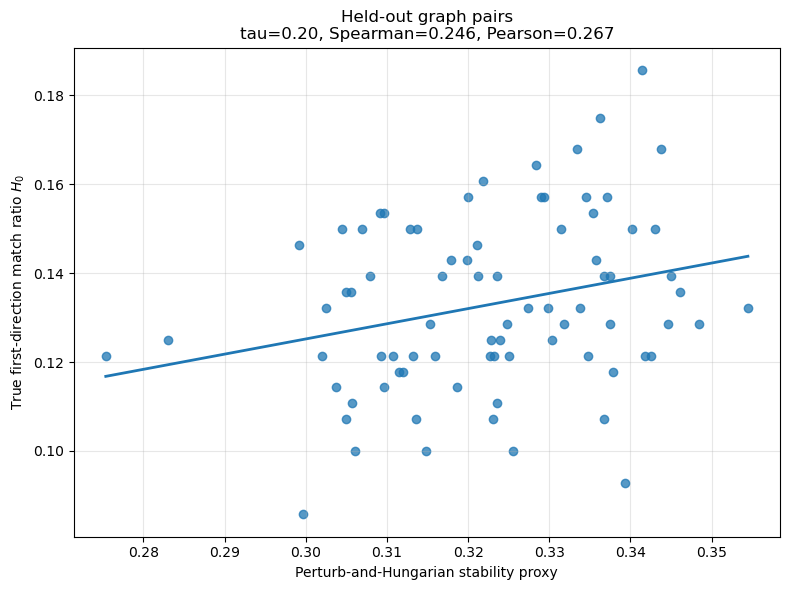


Saved results to: er_perturb_hungarian_proxy_test.pkl


In [75]:
# ============================================================
# TEST PERTURB-AND-HUNGARIAN STABILITY AS A PROXY FOR H0
#
# Main question:
# For the SAME graph pair, does the proxy correctly rank
# candidate seed sets by their true first-direction accuracy H0?
#
# The proxy itself does NOT use true_perm.
# true_perm is used only afterward to evaluate H0 in simulation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr


# ------------------------------------------------------------
# EXPERIMENT SETTINGS
# ------------------------------------------------------------

N_GRAPH_PAIRS = 20
N_CANDIDATE_SEED_SETS = 8
N_SEEDS = 20
N_PERTURBATIONS = 20

# We standardize the first gradient before adding noise,
# so these scales can be compared across graph instances.
TAU_VALUES = np.array([
    0.02,
    0.05,
    0.10,
    0.20,
    0.40,
    0.80,
])

# Start in a transition regime where H0 varies.
ER_N = 300
ER_P = 0.20
ER_RHO = 0.40

RANDOM_SEED = 20260727


# ------------------------------------------------------------
# CHECK THAT THE REQUIRED NOTEBOOK CELLS HAVE BEEN RUN
# ------------------------------------------------------------

required_names = [
    "gen_ER_graphs",
    "graph_match",
    "last_solver",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Run your original setup cell first. Missing names: "
        + ", ".join(missing_names)
    )


# Avoid mixing these runs with earlier alpha diagnostics.
if "clear_first_step_diagnostics" in globals():
    clear_first_step_diagnostics()


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def robust_standardize(matrix):
    """
    Center and robustly scale the gradient.

    Positive rescaling does not change the unperturbed Hungarian
    assignment, but it makes the perturbation parameter tau comparable
    across graph pairs and seed sets.
    """
    matrix = np.asarray(matrix, dtype=float)

    center = np.median(matrix)
    centered = matrix - center

    mad = np.median(np.abs(centered))
    scale = 1.4826 * mad

    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.std(centered)

    if not np.isfinite(scale) or scale < 1e-12:
        scale = 1.0

    return centered / scale


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if (
        len(x) < 2
        or np.isclose(np.std(x), 0.0)
        or np.isclose(np.std(y), 0.0)
    ):
        return np.nan

    return float(spearmanr(x, y).statistic)


def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if (
        len(x) < 2
        or np.isclose(np.std(x), 0.0)
        or np.isclose(np.std(y), 0.0)
    ):
        return np.nan

    return float(pearsonr(x, y).statistic)


def compute_perturbation_proxy(
    solver,
    gradient,
    Q0,
    tau_values,
    n_perturbations,
    rng,
):
    """
    For every tau, repeatedly perturb the standardized first gradient,
    rerun the Hungarian assignment, and measure the fraction of Q0's
    row assignments that remain unchanged.

    Proxy(tau) =
        average over vertices and perturbations of

        1{ perturbed assignment agrees with Q0 }.
    """
    standardized_gradient = robust_standardize(gradient)

    q0_columns = np.argmax(Q0, axis=1)
    n_unseeded = Q0.shape[0]

    proxy_scores = {}

    for tau in tau_values:
        agreement_counts = np.zeros(
            n_unseeded,
            dtype=float,
        )

        for _ in range(n_perturbations):
            noise = rng.standard_normal(
                standardized_gradient.shape
            )

            perturbed_gradient = (
                standardized_gradient
                + float(tau) * noise
            )

            Q_perturbed = solver.compute_step_direction(
                perturbed_gradient,
                rng,
            )

            perturbed_columns = np.argmax(
                Q_perturbed,
                axis=1,
            )

            agreement_counts += (
                perturbed_columns == q0_columns
            )

        row_stabilities = (
            agreement_counts / n_perturbations
        )

        proxy_scores[float(tau)] = float(
            np.mean(row_stabilities)
        )

    return proxy_scores


# ------------------------------------------------------------
# RUN THE EXPERIMENT
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

records = []

total_runs = (
    N_GRAPH_PAIRS
    * N_CANDIDATE_SEED_SETS
)

completed_runs = 0

for graph_id in range(N_GRAPH_PAIRS):

    G1, G2, true_perm = gen_ER_graphs(
        n=ER_N,
        p=ER_P,
        rho=ER_RHO,
    )

    true_perm = np.asarray(
        true_perm,
        dtype=int,
    )

    n_vertices = len(true_perm)

    for candidate_id in range(
        N_CANDIDATE_SEED_SETS
    ):

        # Candidate random seed set.
        seeds_G1 = np.sort(
            rng.choice(
                n_vertices,
                size=N_SEEDS,
                replace=False,
            )
        )

        # These are known seed correspondences.
        seeds_G2 = true_perm[seeds_G1]

        partial_match = np.column_stack(
            (seeds_G1, seeds_G2)
        )

        result = graph_match(
            G1,
            G2,
            partial_match=partial_match,
            rng=int(np.random.randint(0, 2**32)),
        )

        solver = last_solver

        if solver is None:
            raise RuntimeError(
                "The notebook solver patch did not record "
                "the internal solver."
            )

        if len(solver.Q_history_) == 0:
            raise RuntimeError(
                "No first Hungarian direction was recorded."
            )

        # ----------------------------------------------------
        # TRUE H0 — USED ONLY FOR SIMULATION EVALUATION
        # ----------------------------------------------------

        Q0 = solver.Q_history_[0].copy()

        rows_A = solver.perm_A[
            solver.n_seeds:
        ]

        cols_B = solver.perm_B[
            solver.n_seeds:
        ]

        q0_column_positions = np.argmax(
            Q0,
            axis=1,
        )

        q0_predicted_B = cols_B[
            q0_column_positions
        ]

        q0_true_B = true_perm[rows_A]

        H0 = float(
            np.mean(
                q0_predicted_B == q0_true_B
            )
        )

        # ----------------------------------------------------
        # FINAL SGM ACCURACY
        # ----------------------------------------------------

        predicted_perm = np.empty_like(
            true_perm
        )

        predicted_perm[result.indices_A] = (
            result.indices_B
        )

        unseeded_A = np.setdiff1d(
            np.arange(n_vertices),
            seeds_G1,
            assume_unique=False,
        )

        final_unseeded = float(
            np.mean(
                predicted_perm[unseeded_A]
                == true_perm[unseeded_A]
            )
        )

        # ----------------------------------------------------
        # PROXY — DOES NOT USE TRUE_PERM
        # ----------------------------------------------------

        P0 = solver.P_history_[0]

        first_gradient = solver.compute_gradient(
            P0
        )

        proxy_scores = compute_perturbation_proxy(
            solver=solver,
            gradient=first_gradient,
            Q0=Q0,
            tau_values=TAU_VALUES,
            n_perturbations=N_PERTURBATIONS,
            rng=rng,
        )

        record = {
            "graph_id": graph_id,
            "candidate_id": candidate_id,
            "H0": H0,
            "final_unseeded": final_unseeded,
            "alpha0": float(
                solver.alpha_history_[0]
            ),
        }

        for tau, score in proxy_scores.items():
            record[
                f"proxy_tau_{tau:.2f}"
            ] = score

        records.append(record)

        completed_runs += 1

        if (
            completed_runs % 10 == 0
            or completed_runs == total_runs
        ):
            print(
                f"Completed {completed_runs}"
                f"/{total_runs} graph matches"
            )


results_df = pd.DataFrame(records)


# ------------------------------------------------------------
# TRAIN/TEST SPLIT BY GRAPH PAIR
#
# We choose tau using the first half of graph pairs, then report
# results only on graph pairs not used to choose tau.
# ------------------------------------------------------------

n_training_graphs = N_GRAPH_PAIRS // 2

training_graph_ids = np.arange(
    n_training_graphs
)

testing_graph_ids = np.arange(
    n_training_graphs,
    N_GRAPH_PAIRS,
)

training_df = results_df[
    results_df["graph_id"].isin(
        training_graph_ids
    )
].copy()

testing_df = results_df[
    results_df["graph_id"].isin(
        testing_graph_ids
    )
].copy()


# ------------------------------------------------------------
# CHOOSE TAU BY MEAN WITHIN-GRAPH SPEARMAN CORRELATION
# ------------------------------------------------------------

tau_rows = []

for tau in TAU_VALUES:

    proxy_column = (
        f"proxy_tau_{float(tau):.2f}"
    )

    within_graph_correlations = []

    for graph_id, group in training_df.groupby(
        "graph_id"
    ):
        correlation = safe_spearman(
            group[proxy_column],
            group["H0"],
        )

        if np.isfinite(correlation):
            within_graph_correlations.append(
                correlation
            )

    mean_within_graph_spearman = (
        float(
            np.mean(
                within_graph_correlations
            )
        )
        if within_graph_correlations
        else np.nan
    )

    pooled_spearman = safe_spearman(
        training_df[proxy_column],
        training_df["H0"],
    )

    tau_rows.append(
        {
            "tau": float(tau),
            "mean_training_within_graph_spearman":
                mean_within_graph_spearman,
            "training_pooled_spearman":
                pooled_spearman,
            "n_valid_training_graphs":
                len(within_graph_correlations),
        }
    )


tau_results_df = pd.DataFrame(tau_rows)

valid_tau_results = tau_results_df.dropna(
    subset=[
        "mean_training_within_graph_spearman"
    ]
)

if valid_tau_results.empty:
    raise RuntimeError(
        "H0 or the proxy was constant across all "
        "training candidate sets. Try a different rho."
    )

best_tau = float(
    valid_tau_results.sort_values(
        "mean_training_within_graph_spearman",
        ascending=False,
    ).iloc[0]["tau"]
)

best_proxy_column = (
    f"proxy_tau_{best_tau:.2f}"
)


# ------------------------------------------------------------
# HELD-OUT TEST CORRELATIONS
# ------------------------------------------------------------

test_within_graph_rows = []

for graph_id, group in testing_df.groupby(
    "graph_id"
):
    test_within_graph_rows.append(
        {
            "graph_id": int(graph_id),
            "spearman_proxy_H0":
                safe_spearman(
                    group[best_proxy_column],
                    group["H0"],
                ),
            "pearson_proxy_H0":
                safe_pearson(
                    group[best_proxy_column],
                    group["H0"],
                ),
        }
    )


test_within_graph_df = pd.DataFrame(
    test_within_graph_rows
)

valid_test_spearman = (
    test_within_graph_df[
        "spearman_proxy_H0"
    ].dropna()
)

valid_test_pearson = (
    test_within_graph_df[
        "pearson_proxy_H0"
    ].dropna()
)

mean_test_within_spearman = (
    float(valid_test_spearman.mean())
    if len(valid_test_spearman) > 0
    else np.nan
)

median_test_within_spearman = (
    float(valid_test_spearman.median())
    if len(valid_test_spearman) > 0
    else np.nan
)

mean_test_within_pearson = (
    float(valid_test_pearson.mean())
    if len(valid_test_pearson) > 0
    else np.nan
)

test_pooled_spearman = safe_spearman(
    testing_df[best_proxy_column],
    testing_df["H0"],
)

test_pooled_pearson = safe_pearson(
    testing_df[best_proxy_column],
    testing_df["H0"],
)


# ------------------------------------------------------------
# DOES PROXY-BASED SEED SELECTION IMPROVE H0?
# ------------------------------------------------------------

selection_rows = []

for graph_id, group in testing_df.groupby(
    "graph_id"
):

    proxy_selected_row = group.loc[
        group[best_proxy_column].idxmax()
    ]

    oracle_selected_row = group.loc[
        group["H0"].idxmax()
    ]

    selection_rows.append(
        {
            "graph_id": int(graph_id),
            "mean_candidate_H0":
                float(group["H0"].mean()),
            "proxy_selected_H0":
                float(proxy_selected_row["H0"]),
            "oracle_selected_H0":
                float(oracle_selected_row["H0"]),
            "mean_candidate_final":
                float(
                    group[
                        "final_unseeded"
                    ].mean()
                ),
            "proxy_selected_final":
                float(
                    proxy_selected_row[
                        "final_unseeded"
                    ]
                ),
            "oracle_selected_final":
                float(
                    group["final_unseeded"].max()
                ),
        }
    )


selection_df = pd.DataFrame(
    selection_rows
)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("PERTURB-AND-HUNGARIAN PROXY RESULTS")
print("=" * 76)

print(
    f"ER regime: n={ER_N}, p={ER_P}, "
    f"rho={ER_RHO}, seeds={N_SEEDS}"
)

print(
    f"Graph pairs: {N_GRAPH_PAIRS} "
    f"({len(training_graph_ids)} training, "
    f"{len(testing_graph_ids)} testing)"
)

print(
    "Candidate seed sets per graph: "
    f"{N_CANDIDATE_SEED_SETS}"
)

print(
    "Perturbations per tau: "
    f"{N_PERTURBATIONS}"
)

print("\nTraining-scale comparison:")
print(
    tau_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print(
    f"\nSelected tau from training graphs: "
    f"{best_tau:.2f}"
)

print("\nHELD-OUT TEST RESULTS")
print("---------------------")

print(
    "Mean within-graph Spearman(proxy, H0):   "
    f"{mean_test_within_spearman:.4f}"
)

print(
    "Median within-graph Spearman(proxy, H0): "
    f"{median_test_within_spearman:.4f}"
)

print(
    "Mean within-graph Pearson(proxy, H0):    "
    f"{mean_test_within_pearson:.4f}"
)

print(
    "Pooled held-out Spearman(proxy, H0):     "
    f"{test_pooled_spearman:.4f}"
)

print(
    "Pooled held-out Pearson(proxy, H0):      "
    f"{test_pooled_pearson:.4f}"
)

print("\nSEED-SELECTION TEST")
print("-------------------")

print(
    "Mean H0 of all candidate seed sets:      "
    f"{selection_df['mean_candidate_H0'].mean():.4f}"
)

print(
    "Mean H0 selected by proxy:               "
    f"{selection_df['proxy_selected_H0'].mean():.4f}"
)

print(
    "Mean oracle-best H0:                     "
    f"{selection_df['oracle_selected_H0'].mean():.4f}"
)

print(
    "Mean final accuracy of all candidates:   "
    f"{selection_df['mean_candidate_final'].mean():.4f}"
)

print(
    "Mean final accuracy selected by proxy:   "
    f"{selection_df['proxy_selected_final'].mean():.4f}"
)

print(
    "Mean oracle-best final accuracy:         "
    f"{selection_df['oracle_selected_final'].mean():.4f}"
)


# ------------------------------------------------------------
# HELD-OUT SCATTERPLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    testing_df[best_proxy_column],
    testing_df["H0"],
    alpha=0.75,
)

if (
    not np.isclose(
        testing_df[
            best_proxy_column
        ].std(),
        0.0,
    )
):
    slope, intercept = np.polyfit(
        testing_df[best_proxy_column],
        testing_df["H0"],
        1,
    )

    x_line = np.linspace(
        testing_df[
            best_proxy_column
        ].min(),
        testing_df[
            best_proxy_column
        ].max(),
        200,
    )

    plt.plot(
        x_line,
        slope * x_line + intercept,
        linewidth=2,
    )

plt.xlabel(
    "Perturb-and-Hungarian stability proxy"
)

plt.ylabel(
    r"True first-direction match ratio $H_0$"
)

plt.title(
    "Held-out graph pairs\n"
    f"tau={best_tau:.2f}, "
    f"Spearman={test_pooled_spearman:.3f}, "
    f"Pearson={test_pooled_pearson:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE EVERYTHING
# ------------------------------------------------------------

output = {
    "settings": {
        "n_graph_pairs": N_GRAPH_PAIRS,
        "n_candidate_seed_sets":
            N_CANDIDATE_SEED_SETS,
        "n_seeds": N_SEEDS,
        "n_perturbations":
            N_PERTURBATIONS,
        "tau_values": TAU_VALUES,
        "er_n": ER_N,
        "er_p": ER_P,
        "er_rho": ER_RHO,
        "random_seed": RANDOM_SEED,
    },
    "best_tau": best_tau,
    "records": results_df,
    "tau_results": tau_results_df,
    "test_within_graph_correlations":
        test_within_graph_df,
    "selection_results": selection_df,
}

pd.to_pickle(
    output,
    "er_perturb_hungarian_proxy_test.pkl",
)

print(
    "\nSaved results to: "
    "er_perturb_hungarian_proxy_test.pkl"
)

First-step diagnostic records cleared.
Completed 20/360 graph matches
Completed 40/360 graph matches
Completed 60/360 graph matches
Completed 80/360 graph matches
Completed 100/360 graph matches
Completed 120/360 graph matches
Completed 140/360 graph matches
Completed 160/360 graph matches
Completed 180/360 graph matches
Completed 200/360 graph matches
Completed 220/360 graph matches
Completed 240/360 graph matches
Completed 260/360 graph matches
Completed 280/360 graph matches
Completed 300/360 graph matches
Completed 320/360 graph matches
Completed 340/360 graph matches
Completed 360/360 graph matches

CENTERED SEED-SIGNATURE PROXY RESULTS
ER regime: n=300, p=0.2, rho=0.4, seeds=20
Graph pairs: 30
Candidate seed sets per graph: 12
Total graph matches: 360

CORRELATIONS WITH TRUE H0
-------------------------
               proxy  mean_within_graph_spearman  median_within_graph_spearman  mean_within_graph_pearson  pooled_spearman  pooled_pearson  valid_graphs
     M_seed_centered      

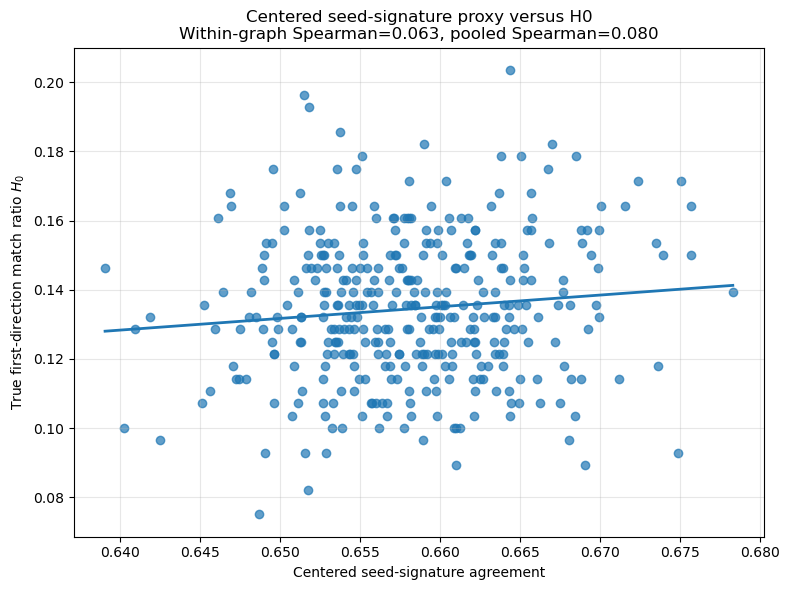


Saved results to: er_centered_seed_signature_proxy_test.pkl


In [77]:
# ============================================================
# TEST CENTERED SEED-SIGNATURE AGREEMENT AS A PROXY FOR H0
#
# Goal:
# For each fixed graph pair, generate candidate seed sets and test
# whether maximizing the computable metric M_seed_centered also
# tends to maximize the true first-direction match ratio H0.
#
# The proxy does NOT use true_perm on unseeded vertices.
# true_perm is used only afterward to evaluate the proxy.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr


# ------------------------------------------------------------
# EXPERIMENT SETTINGS
# ------------------------------------------------------------

N_GRAPH_PAIRS = 30
N_CANDIDATE_SEED_SETS = 12
N_SEEDS = 20

ER_N = 300
ER_P = 0.20
ER_RHO = 0.40

RANDOM_SEED = 20260727


# ------------------------------------------------------------
# CHECK NOTEBOOK SETUP
# ------------------------------------------------------------

required_names = [
    "gen_ER_graphs",
    "graph_match",
    "last_solver",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Run your original notebook setup cell and solver patch first. "
        "Missing names: " + ", ".join(missing_names)
    )

if "clear_first_step_diagnostics" in globals():
    clear_first_step_diagnostics()


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def to_dense_array(matrix):
    """Convert dense or sparse adjacency matrices to NumPy arrays."""
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()

    return np.asarray(matrix, dtype=float)


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if (
        len(x) < 2
        or np.isclose(np.std(x), 0.0)
        or np.isclose(np.std(y), 0.0)
    ):
        return np.nan

    return float(spearmanr(x, y).statistic)


def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if (
        len(x) < 2
        or np.isclose(np.std(x), 0.0)
        or np.isclose(np.std(y), 0.0)
    ):
        return np.nan

    return float(pearsonr(x, y).statistic)


def centered_seed_signature_proxy(
    A,
    B,
    rows_A,
    predicted_B,
    seeds_A,
    seeds_B,
):
    """
    Compute centered seed-signature agreement for Q0.

    X[i,k] = adjacency in graph A between unseeded vertex rows_A[i]
             and seed seeds_A[k].

    Y[i,k] = adjacency in graph B between Q0's proposed partner
             predicted_B[i] and the matched seed seeds_B[k].

    Correct Q0 matches should cause X and Y to retain correlated
    seed-adjacency patterns.
    """
    A = to_dense_array(A)
    B = to_dense_array(B)

    X = A[np.ix_(rows_A, seeds_A)]
    Y = B[np.ix_(predicted_B, seeds_B)]

    # Global centering is appropriate for this ER experiment.
    X_centered = X - np.mean(X)
    Y_centered = Y - np.mean(Y)

    denominator = (
        np.linalg.norm(X_centered)
        * np.linalg.norm(Y_centered)
    )

    if denominator < 1e-12:
        centered_score = np.nan
    else:
        centered_score = float(
            np.sum(X_centered * Y_centered)
            / denominator
        )

    # Also record raw agreement as a simple baseline.
    raw_agreement = float(
        np.mean(X == Y)
    )

    # Positive-edge agreement is another interpretable baseline.
    union_count = np.sum((X == 1) | (Y == 1))

    if union_count == 0:
        edge_jaccard = np.nan
    else:
        edge_jaccard = float(
            np.sum((X == 1) & (Y == 1))
            / union_count
        )

    return {
        "M_seed_centered": centered_score,
        "M_seed_raw_agreement": raw_agreement,
        "M_seed_edge_jaccard": edge_jaccard,
    }


# ------------------------------------------------------------
# RUN EXPERIMENT
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

records = []

total_runs = (
    N_GRAPH_PAIRS
    * N_CANDIDATE_SEED_SETS
)

completed_runs = 0

for graph_id in range(N_GRAPH_PAIRS):

    G1, G2, true_perm = gen_ER_graphs(
        n=ER_N,
        p=ER_P,
        rho=ER_RHO,
    )

    true_perm = np.asarray(
        true_perm,
        dtype=int,
    )

    n_vertices = len(true_perm)

    for candidate_id in range(
        N_CANDIDATE_SEED_SETS
    ):

        # Candidate seed set in graph A.
        seeds_A = np.sort(
            rng.choice(
                n_vertices,
                size=N_SEEDS,
                replace=False,
            )
        )

        # Known matched seed partners in graph B.
        seeds_B = true_perm[seeds_A]

        partial_match = np.column_stack(
            (seeds_A, seeds_B)
        )

        result = graph_match(
            G1,
            G2,
            partial_match=partial_match,
            rng=int(np.random.randint(0, 2**32)),
        )

        solver = last_solver

        if solver is None:
            raise RuntimeError(
                "No internal solver was recorded. "
                "Run the solver-history patch first."
            )

        if len(solver.Q_history_) == 0:
            raise RuntimeError(
                "No first Hungarian direction was recorded."
            )

        Q0 = solver.Q_history_[0].copy()

        # Internal unseeded labels in the exact ordering used by Q0.
        rows_A = np.asarray(
            solver.perm_A[solver.n_seeds:],
            dtype=int,
        )

        cols_B = np.asarray(
            solver.perm_B[solver.n_seeds:],
            dtype=int,
        )

        q0_column_positions = np.argmax(
            Q0,
            axis=1,
        )

        predicted_B_from_Q0 = cols_B[
            q0_column_positions
        ]

        # ----------------------------------------------------
        # TRUE H0: evaluation only
        # ----------------------------------------------------

        true_B_for_rows = true_perm[rows_A]

        H0 = float(
            np.mean(
                predicted_B_from_Q0
                == true_B_for_rows
            )
        )

        # ----------------------------------------------------
        # COMPUTABLE PROXY: does not use true unseeded matches
        # ----------------------------------------------------

        proxy_scores = centered_seed_signature_proxy(
            A=G1,
            B=G2,
            rows_A=rows_A,
            predicted_B=predicted_B_from_Q0,
            seeds_A=seeds_A,
            seeds_B=seeds_B,
        )

        # ----------------------------------------------------
        # FINAL SGM ACCURACY
        # ----------------------------------------------------

        predicted_perm = np.empty_like(
            true_perm
        )

        predicted_perm[result.indices_A] = (
            result.indices_B
        )

        unseeded_A = np.setdiff1d(
            np.arange(n_vertices),
            seeds_A,
        )

        final_unseeded = float(
            np.mean(
                predicted_perm[unseeded_A]
                == true_perm[unseeded_A]
            )
        )

        records.append(
            {
                "graph_id": graph_id,
                "candidate_id": candidate_id,
                "H0": H0,
                "final_unseeded": final_unseeded,
                "alpha0": float(
                    solver.alpha_history_[0]
                ),
                **proxy_scores,
            }
        )

        completed_runs += 1

        if (
            completed_runs % 20 == 0
            or completed_runs == total_runs
        ):
            print(
                f"Completed {completed_runs}"
                f"/{total_runs} graph matches"
            )


results_df = pd.DataFrame(records)


# ------------------------------------------------------------
# CORRELATION ANALYSIS
# ------------------------------------------------------------

proxy_columns = [
    "M_seed_centered",
    "M_seed_raw_agreement",
    "M_seed_edge_jaccard",
]

summary_rows = []
within_graph_records = []

for proxy_column in proxy_columns:

    graph_spearman_values = []
    graph_pearson_values = []

    for graph_id, group in results_df.groupby(
        "graph_id"
    ):
        spearman_value = safe_spearman(
            group[proxy_column],
            group["H0"],
        )

        pearson_value = safe_pearson(
            group[proxy_column],
            group["H0"],
        )

        within_graph_records.append(
            {
                "graph_id": int(graph_id),
                "proxy": proxy_column,
                "spearman_proxy_H0":
                    spearman_value,
                "pearson_proxy_H0":
                    pearson_value,
            }
        )

        if np.isfinite(spearman_value):
            graph_spearman_values.append(
                spearman_value
            )

        if np.isfinite(pearson_value):
            graph_pearson_values.append(
                pearson_value
            )

    pooled_spearman = safe_spearman(
        results_df[proxy_column],
        results_df["H0"],
    )

    pooled_pearson = safe_pearson(
        results_df[proxy_column],
        results_df["H0"],
    )

    summary_rows.append(
        {
            "proxy": proxy_column,
            "mean_within_graph_spearman":
                float(np.mean(graph_spearman_values))
                if graph_spearman_values
                else np.nan,
            "median_within_graph_spearman":
                float(np.median(graph_spearman_values))
                if graph_spearman_values
                else np.nan,
            "mean_within_graph_pearson":
                float(np.mean(graph_pearson_values))
                if graph_pearson_values
                else np.nan,
            "pooled_spearman":
                pooled_spearman,
            "pooled_pearson":
                pooled_pearson,
            "valid_graphs":
                len(graph_spearman_values),
        }
    )


summary_df = pd.DataFrame(summary_rows)

within_graph_df = pd.DataFrame(
    within_graph_records
)


# ------------------------------------------------------------
# SEED-SELECTION TEST
# ------------------------------------------------------------

selection_rows = []

for graph_id, group in results_df.groupby(
    "graph_id"
):

    row = {
        "graph_id": int(graph_id),
        "mean_candidate_H0":
            float(group["H0"].mean()),
        "oracle_best_H0":
            float(group["H0"].max()),
        "mean_candidate_final":
            float(
                group["final_unseeded"].mean()
            ),
    }

    for proxy_column in proxy_columns:

        valid_group = group.dropna(
            subset=[proxy_column]
        )

        if valid_group.empty:
            row[
                f"{proxy_column}_selected_H0"
            ] = np.nan

            row[
                f"{proxy_column}_selected_final"
            ] = np.nan

            continue

        selected_row = valid_group.loc[
            valid_group[proxy_column].idxmax()
        ]

        row[
            f"{proxy_column}_selected_H0"
        ] = float(selected_row["H0"])

        row[
            f"{proxy_column}_selected_final"
        ] = float(
            selected_row["final_unseeded"]
        )

    selection_rows.append(row)


selection_df = pd.DataFrame(
    selection_rows
)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("CENTERED SEED-SIGNATURE PROXY RESULTS")
print("=" * 78)

print(
    f"ER regime: n={ER_N}, p={ER_P}, "
    f"rho={ER_RHO}, seeds={N_SEEDS}"
)

print(
    f"Graph pairs: {N_GRAPH_PAIRS}"
)

print(
    "Candidate seed sets per graph: "
    f"{N_CANDIDATE_SEED_SETS}"
)

print(
    f"Total graph matches: {len(results_df)}"
)

print("\nCORRELATIONS WITH TRUE H0")
print("-------------------------")

print(
    summary_df.to_string(
        index=False,
        float_format=lambda value:
            f"{value:.4f}",
    )
)

print("\nSEED-SELECTION PERFORMANCE")
print("--------------------------")

print(
    "Mean H0 over all candidate seed sets: "
    f"{selection_df['mean_candidate_H0'].mean():.4f}"
)

print(
    "Mean oracle-best H0:                 "
    f"{selection_df['oracle_best_H0'].mean():.4f}"
)

for proxy_column in proxy_columns:

    print(
        f"Mean H0 selected by {proxy_column}: "
        f"{selection_df[f'{proxy_column}_selected_H0'].mean():.4f}"
    )

print(
    "\nMean final accuracy over candidates: "
    f"{selection_df['mean_candidate_final'].mean():.4f}"
)

for proxy_column in proxy_columns:

    print(
        f"Mean final selected by {proxy_column}: "
        f"{selection_df[f'{proxy_column}_selected_final'].mean():.4f}"
    )


# ------------------------------------------------------------
# SCATTERPLOT FOR MAIN PROXY
# ------------------------------------------------------------

main_proxy = "M_seed_centered"

main_summary = summary_df[
    summary_df["proxy"] == main_proxy
].iloc[0]

plt.figure(figsize=(8, 6))

plt.scatter(
    results_df[main_proxy],
    results_df["H0"],
    alpha=0.7,
)

valid_plot = results_df[
    [main_proxy, "H0"]
].dropna()

if (
    len(valid_plot) >= 2
    and not np.isclose(
        valid_plot[main_proxy].std(),
        0.0,
    )
):
    slope, intercept = np.polyfit(
        valid_plot[main_proxy],
        valid_plot["H0"],
        1,
    )

    x_line = np.linspace(
        valid_plot[main_proxy].min(),
        valid_plot[main_proxy].max(),
        200,
    )

    plt.plot(
        x_line,
        slope * x_line + intercept,
        linewidth=2,
    )

plt.xlabel(
    "Centered seed-signature agreement"
)

plt.ylabel(
    r"True first-direction match ratio $H_0$"
)

plt.title(
    "Centered seed-signature proxy versus H0\n"
    f"Within-graph Spearman="
    f"{main_summary['mean_within_graph_spearman']:.3f}, "
    f"pooled Spearman="
    f"{main_summary['pooled_spearman']:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

output = {
    "settings": {
        "n_graph_pairs": N_GRAPH_PAIRS,
        "n_candidate_seed_sets":
            N_CANDIDATE_SEED_SETS,
        "n_seeds": N_SEEDS,
        "er_n": ER_N,
        "er_p": ER_P,
        "er_rho": ER_RHO,
        "random_seed": RANDOM_SEED,
    },
    "records": results_df,
    "correlation_summary": summary_df,
    "within_graph_correlations":
        within_graph_df,
    "selection_results": selection_df,
}

pd.to_pickle(
    output,
    "er_centered_seed_signature_proxy_test.pkl",
)

print(
    "\nSaved results to: "
    "er_centered_seed_signature_proxy_test.pkl"
)